
## 0.1 Setup and Dependencies

Before running this notebook, ensure all required packages are installed. You can install them using the `requirements.txt` file:

```bash
pip install -r requirements.txt
```

Alternatively, individual packages can be installed as needed.


## Capstone Project 
### eCommerce Product Recommendation Using MovieLens as a Proxy Dataset

**Purpose:** This notebook is designed to cover the following perspectives with regards to the Project:

- Step 1: Problem understanding and framing
- Step 2: Data collection and understanding
- Step 3: Preprocessing, applied EDA, feature engineering, feature selection, and dimensionality reduction
- Step 4: Model implementation and comparison
- Step 5: Explainability, ethical AI, and bias auditing
- Step 6–7 support: outputs structured for presentation and GitHub submission

**Project framing:** 
MovieLens is used as a proxy for eCommerce recommendation because both problems involve sparse user-item interactions, ranking decisions, long-tail catalogs, popularity bias, and personalization objectives.

**Expected dataset location:** 
- https://grouplens.org/datasets/movielens/ 
- Place `ml-latest-small.zip` under `data/raw/`.

**Recommended execution order:** Run cells from top to bottom.

#### Citation

F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. https://doi.org/10.1145/2827872

## Notebook features:

##### | Step 1 | Business problem, task type, technical metrics, business KPI proxies |
##### | Step 2 | Dataset justification, overview, data dictionary, missing values and distributions |
##### | Step 3 | Cleaning, preprocessing, EDA, feature engineering, feature selection, PCA, t-SNE-ready embeddings |
##### | Step 4 | Multiple recommenders: popularity, item-item KNN, matrix factorization, content-based, hybrid, optional reranker |
##### | Step 5 | Explainability, limitations, popularity-bias audit, group-based fairness checks, mitigation ideas |
##### | Step 6 | Saved artifacts, reproducible paths, notebook-ready GitHub folder conventions |


## 1. Problem framing

### Business problem
Digital commerce platforms often struggle to surface the most relevant products to each user, leading to low engagement, weaker conversion, and missed cross-sell opportunities. In this project, the problem is framed as a Top-N recommendation / ranking task: predicting which products a user is most likely to prefer based on past interaction history. Using the MovieLens dataset as a proxy for eCommerce user-item behavior, success will be measured primarily using NDCG@10 and Precision@10, since the business objective is to rank the most relevant items near the top of the recommendation list. Secondary metrics will include Recall@10, MAP@10, and catalog coverage. From a business perspective, the target outcome is to improve recommendation relevance, increase user engagement, and broaden useful item exposure across the catalog.

### Data science problem
Build a **Top-N recommendation system** that predicts which items each user is most likely to prefer, based on historical user-item interactions.

### Why MovieLens is a valid proxy for eCommerce
Although MovieLens is a movie-rating dataset rather than a retail transaction dataset, the recommendation mechanics are closely related:

- Users correspond to customers
- Movies correspond to products
- Ratings correspond to explicit preference signals
- Tags and genres correspond to product metadata
- The item catalog is sparse and long-tailed

### Task type
**Recommendation / ranking**

### Technical success metrics
- Precision\@K
- Recall\@K
- MAP\@K
- NDCG\@K
- RMSE and MAE for rating-oriented models
- Catalog coverage and diversity proxies

### Business KPI proxies
- Recommendation Click-Through Rate (CTR) uplift
- Engagement uplift
- Catalog exposure breadth
- Repeat-session likelihood proxy
- Improved relevance of surfaced items


### Methodology Justification and Limitations

#### Why this Methodology?
- **Chronological Split:** Unlike a random split, a chronological split simulates a real-world production environment where we train on past data to predict future behavior. This prevents "temporal leakage" where the model might inadvertently learn from the future.
- **Sparse Matrix (CSR):** Real-world eCommerce data is extremely sparse (most users only interact with a tiny fraction of the catalog). Using a Compressed Sparse Row (CSR) matrix is memory-efficient and avoids the bias of filling missing values with zeros, which would incorrectly imply a negative preference.
- **Hybrid Approach:** No single model is perfect. Collaborative filtering (SVD/KNN) captures user-item patterns, while Content-Based filtering handles the "cold-start" problem for new items. Combining them provides a more robust system.

#### Limitations
- **Cold Start:** Even with content-based fallbacks, new users with no history remain difficult to recommend for accurately.
- **Dataset Proxy:** While MovieLens is a great proxy, it lacks real eCommerce signals like "add to cart," "view duration," or "price sensitivity."
- **Offline Evaluation:** Metrics like NDCG and Precision are proxies for business value. True performance can only be validated through online A/B testing.


## 2. Data collection and understanding

### Dataset choice
This notebook uses the **MovieLens latest small** dataset because it is public, well-known, reproducible, and manageable submission for the GitHub repo.

### Expected files after extraction
- `ratings.csv`
- `movies.csv`
- `tags.csv`
- `links.csv`

### Data dictionary requirement
A complete data dictionary is generated below for variable-level documentation.

In [2]:
# Core imports
import os
import json
import pickle
import math
import random
import zipfile
import warnings
from pathlib import Path
from collections import defaultdict

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 200)
np.random.seed(42)
random.seed(42)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
INTERIM_DIR = DATA_DIR / 'interim'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR = BASE_DIR / 'models'
REPORT_DIR = BASE_DIR / 'reports'
FIG_DIR = REPORT_DIR / 'figures'
TABLES_DIR = REPORT_DIR / 'tables'

for path in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, MODEL_DIR, REPORT_DIR, FIG_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'dataset_zip_name': 'ml-latest-small.zip',
    'min_user_interactions': 20,
    'min_item_interactions': 25,
    'min_item_grid': [25, 50, 100],
    'knn_grid': [10, 20, 40],
    'candidate_k': 100,
    'top_k_eval': 10,
    'latent_factors': 50,
    'hybrid_weights': {
        'popularity': 0.15,
        'item_knn': 0.35,
        'svd': 0.30,
        'content': 0.20,
    },
    'rating_like_threshold': 4.0,
    'test_fraction_per_user': 0.2,
    'validation_fraction_per_user': 0.2,
}

CONFIG

{'dataset_zip_name': 'ml-latest-small.zip',
 'min_user_interactions': 20,
 'min_item_interactions': 25,
 'min_item_grid': [25, 50, 100],
 'knn_grid': [10, 20, 40],
 'candidate_k': 100,
 'top_k_eval': 10,
 'latent_factors': 50,
 'hybrid_weights': {'popularity': 0.15,
  'item_knn': 0.35,
  'svd': 0.3,
  'content': 0.2},
 'rating_like_threshold': 4.0,
 'test_fraction_per_user': 0.2,
 'validation_fraction_per_user': 0.2}

In [3]:

# Generate requirements.txt for reproducibility
!pip freeze > requirements.txt
print("Generated requirements.txt")


Generated requirements.txt


In [4]:

# Reproducibility and project paths
RANDOM_STATE = 42
TOP_K = 10

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

for directory in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Project folders prepared.")

Project folders prepared.



## Data Loading and Dataset Overview

Expected MovieLens small files after extraction:
- `ratings.csv`
- `movies.csv`
- `tags.csv`
- `links.csv`

The helper below extracts the dataset if a local zip is available.


In [5]:

def ensure_movielens_extracted(raw_dir: Path, zip_name: str = 'ml-latest-small.zip') -> Path:
    """Ensures the MovieLens dataset is extracted and available.

    Checks if the dataset is already extracted. If not, it attempts to extract
    the specified zip file into the raw data directory. Raises FileNotFoundError
    if the zip file is not found.

    Args:
        raw_dir (Path): The path to the raw data directory.
        zip_name (str): The name of the MovieLens zip file.

    Returns:
        Path: The path to the extracted MovieLens dataset directory.

    Raises:
        FileNotFoundError: If the MovieLens zip file is not found.
    """
    zip_path = raw_dir / zip_name
    extract_dir = raw_dir / 'ml-latest-small'
    # Check if the dataset is already extracted
    if extract_dir.exists() and (extract_dir / 'ratings.csv').exists():
        return extract_dir
    # If not extracted, check if the zip file exists and extract it
    if zip_path.exists():
        print(f"Extracting {zip_name} to {raw_dir}...")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(raw_dir)
        return extract_dir
    # If zip file is not found, raise an error
    raise FileNotFoundError(
        f"Could not find {zip_path}. Download MovieLens small and place it in {raw_dir}."
    )


In [6]:

def dataset_overview(ratings: pd.DataFrame, movies: pd.DataFrame, tags: pd.DataFrame, links: pd.DataFrame) -> pd.DataFrame:
    overview = pd.DataFrame([
        {'table': 'ratings', 'rows': len(ratings), 'columns': ratings.shape[1], 'missing_values': int(ratings.isna().sum().sum())},
        {'table': 'movies', 'rows': len(movies), 'columns': movies.shape[1], 'missing_values': int(movies.isna().sum().sum())},
        {'table': 'tags', 'rows': len(tags), 'columns': tags.shape[1], 'missing_values': int(tags.isna().sum().sum())},
        {'table': 'links', 'rows': len(links), 'columns': links.shape[1], 'missing_values': int(links.isna().sum().sum())},
    ])
    return overview


if 'ratings' in globals():
    display(dataset_overview(ratings, movies, tags, links))


In [7]:

def build_data_dictionary() -> pd.DataFrame:
    """Constructs a data dictionary for the MovieLens dataset.

    Returns:
        pd.DataFrame: A DataFrame detailing each column across the MovieLens tables,
                      including its type, description, and any specific notes.
    """
    return pd.DataFrame([
        ['ratings', 'userId', 'integer', 'Unique user identifier', ''],
        ['ratings', 'movieId', 'integer', 'Unique item identifier', ''],
        ['ratings', 'rating', 'float', 'Explicit preference score on a 0.5 to 5.0 scale', 'Target variable for rating prediction, used to derive implicit feedback'],
        ['ratings', 'timestamp', 'datetime', 'Interaction timestamp', ''],
        ['movies', 'movieId', 'integer', 'Unique item identifier', ''],
        ['movies', 'title', 'string', 'Movie title with year', ''],
        ['movies', 'genres', 'string', 'Pipe-separated genre labels', 'Used for content-based features'],
        ['tags', 'userId', 'integer', 'User identifier for free-text tag', ''],
        ['tags', 'movieId', 'integer', 'Item identifier for free-text tag', ''],
        ['tags', 'tag', 'string', 'User-generated tag text', 'Used for TF-IDF content features'],
        ['tags', 'timestamp', 'datetime', 'Tag timestamp', ''],
        ['links', 'movieId', 'integer', 'Item identifier', ''],
        ['links', 'imdbId', 'integer', 'IMDb mapping', 'External link identifier'],
        ['links', 'tmdbId', 'integer', 'TMDb mapping', 'External link identifier'],
    ], columns=['table', 'column', 'dtype', 'description', 'notes'])


### Run data loading
The next cell extracts the zip file if needed and loads all required tables.


In [8]:

data_dir = ensure_movielens_extracted(RAW_DIR, zip_name="ml-latest-small.zip")
ratings = pd.read_csv(data_dir / "ratings.csv")
movies = pd.read_csv(data_dir / "movies.csv")
tags = pd.read_csv(data_dir / "tags.csv")
links = pd.read_csv(data_dir / "links.csv")

overview_df = dataset_overview(ratings, movies, tags, links)
data_dictionary_df = build_data_dictionary()

display(overview_df)
display(data_dictionary_df)

data_dictionary_df.to_csv(TABLES_DIR / "data_dictionary.csv", index=False)
overview_df.to_csv(TABLES_DIR / "dataset_overview.csv", index=False)


,table,rows,columns,missing_values
0,ratings,100836,4,0
1,movies,9742,3,0
2,tags,3683,4,0
3,links,9742,3,8


,table,column,dtype,description,notes
0,ratings,userId,integer,Unique user identifier,
1,ratings,movieId,integer,Unique item identifier,
2,ratings,rating,float,Explicit preference score on a 0.5 to 5.0 scale,"Target variable for rating prediction, used to..."
3,ratings,timestamp,datetime,Interaction timestamp,
4,movies,movieId,integer,Unique item identifier,
5,movies,title,string,Movie title with year,
6,movies,genres,string,Pipe-separated genre labels,Used for content-based features
7,tags,userId,integer,User identifier for free-text tag,
8,tags,movieId,integer,Item identifier for free-text tag,
9,tags,tag,string,User-generated tag text,Used for TF-IDF content features



## 3. Data Quality Checks and Preprocessing

This section handles duplicates, basic missingness, rating range checks, and prepares metadata for downstream feature engineering.


In [9]:
def preprocess_movielens(ratings: pd.DataFrame, movies: pd.DataFrame, tags: pd.DataFrame):
    ratings = ratings.copy()
    movies = movies.copy()
    tags = tags.copy()

    ratings = ratings.drop_duplicates()
    movies = movies.drop_duplicates(subset=['movieId'])
    tags = tags.drop_duplicates()

    ratings = ratings[(ratings['rating'] >= 0.5) & (ratings['rating'] <= 5.0)]

    # Convert Unix timestamps once during preprocessing so every downstream cell
    # works with proper datetime values.
    if 'timestamp' in ratings.columns:
        if not pd.api.types.is_datetime64_any_dtype(ratings['timestamp']):
            ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s', errors='coerce')
        else:
            ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], errors='coerce')

    if 'timestamp' in tags.columns:
        if not pd.api.types.is_datetime64_any_dtype(tags['timestamp']):
            tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s', errors='coerce')
        else:
            tags['timestamp'] = pd.to_datetime(tags['timestamp'], errors='coerce')

    movies['genres_list'] = movies['genres'].fillna('(no genres listed)').str.split('|')
    movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
    movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)

    tag_agg = (
        tags.groupby('movieId')['tag']
        .apply(lambda x: ' '.join(sorted(set([str(v).lower() for v in x if pd.notna(v)]))))
        .reset_index(name='tag_text')
    )

    movies = movies.merge(tag_agg, on='movieId', how='left')
    movies['tag_text'] = movies['tag_text'].fillna('')
    movies['content_text'] = (
        movies['clean_title'].fillna('') + ' ' +
        movies['genres'].fillna('') + ' ' +
        movies['tag_text']
    )

    return ratings, movies, tags


if 'ratings' in globals():
    ratings_prep, movies_prep, tags_prep = preprocess_movielens(ratings, movies, tags)
    print(ratings_prep.shape, movies_prep.shape, tags_prep.shape)
    print("ratings_prep timestamp dtype:", ratings_prep['timestamp'].dtype)
    print("ratings_prep timestamp nulls:", ratings_prep['timestamp'].isna().sum())
    print("ratings_prep timestamp range:", ratings_prep['timestamp'].min(), "to", ratings_prep['timestamp'].max())


(100836, 4) (9742, 8) (3683, 4)
ratings_prep timestamp dtype: datetime64[ns]
ratings_prep timestamp nulls: 0
ratings_prep timestamp range: 1996-03-29 18:36:55 to 2018-09-24 14:27:30


In [10]:
def summarize_data_quality(ratings: pd.DataFrame, movies: pd.DataFrame, tags: pd.DataFrame) -> pd.DataFrame:
    checks = []
    for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags)]:
        # For movies, exclude 'genres_list' from the duplicated check as it contains unhashable lists
        if name == 'movies' and 'genres_list' in df.columns:
            duplicates_count = int(df.drop(columns=['genres_list']).duplicated().sum())
        else:
            duplicates_count = int(df.duplicated().sum())

        checks.append({
            'table': name,
            'rows': len(df),
            'duplicates': duplicates_count,
            'missing_values': int(df.isna().sum().sum()),
        })
    return pd.DataFrame(checks)


if 'ratings_prep' in globals():
    display(summarize_data_quality(ratings_prep, movies_prep, tags_prep))


,table,rows,duplicates,missing_values
0,ratings,100836,0,0
1,movies,9742,0,13
2,tags,3683,0,0


In [11]:

ratings_clean, movies_enriched, tags_clean = preprocess_movielens(ratings, movies, tags)
quality_df = summarize_data_quality(ratings_clean, movies_enriched, tags_clean)
display(quality_df)
quality_df.to_csv(TABLES_DIR / "data_quality_checks.csv", index=False)

print("Ratings shape:", ratings_clean.shape)
print("Movies shape:", movies_enriched.shape)
print("Tags shape:", tags_clean.shape)


,table,rows,duplicates,missing_values
0,ratings,100836,0,0
1,movies,9742,0,13
2,tags,3683,0,0


Ratings shape: (100836, 4)
Movies shape: (9742, 8)
Tags shape: (3683, 4)


## 3. Applied EDA

Visual exploration of distributions, relationships, sparsity, and data behavior. This section produces plot-ready outputs for reports.
Distributions, relationships, and insight-backed visuals are covered. The plots below cover user activity, item popularity, long-tail behavior, and rating trends.


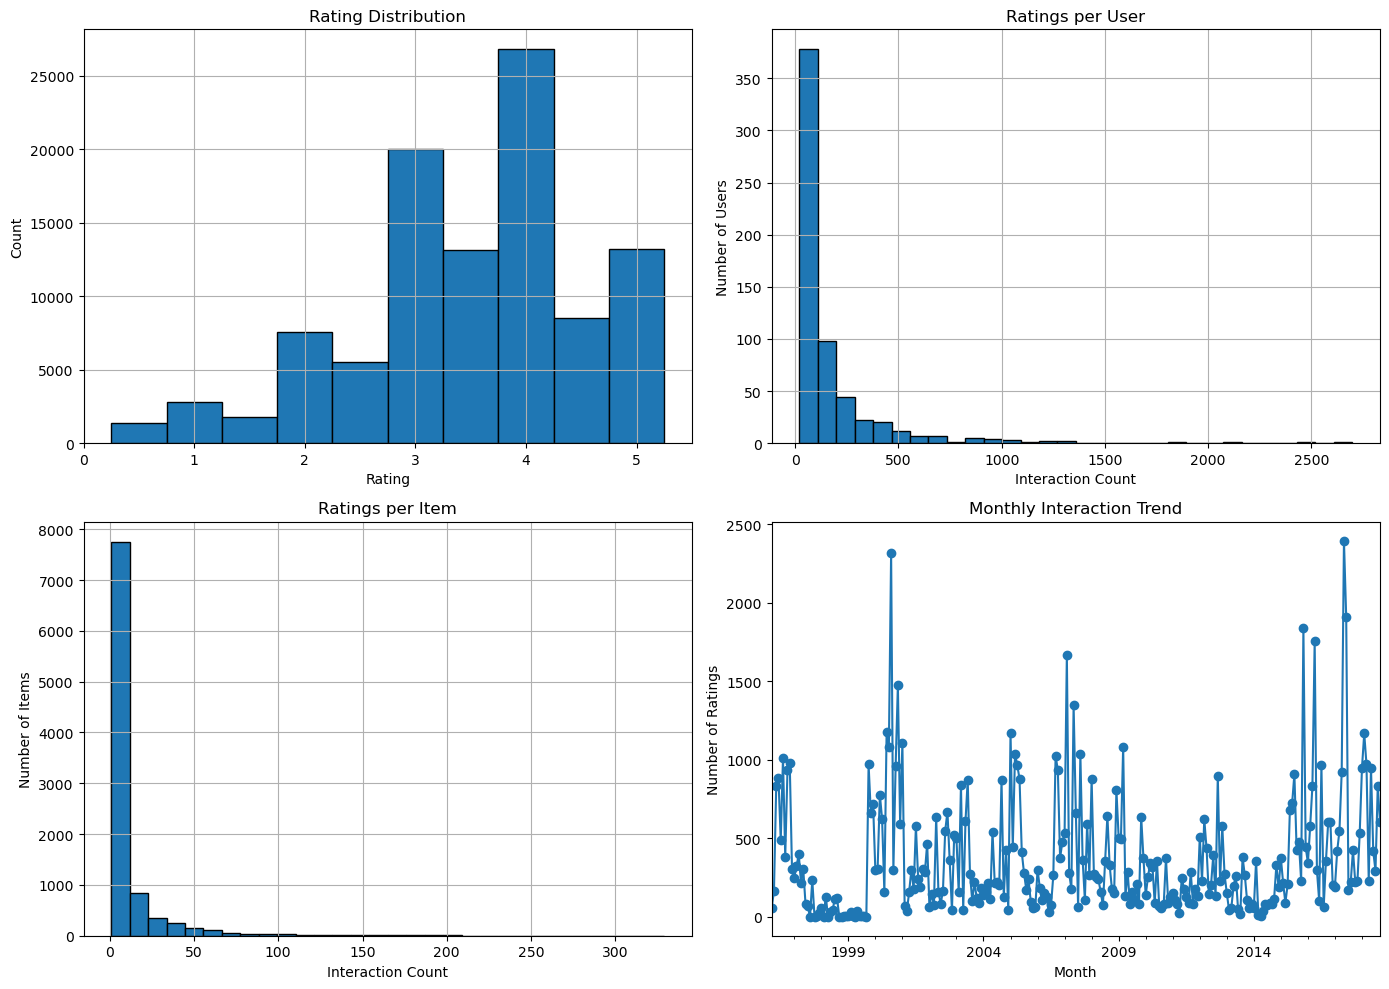

Monthly series head:
timestamp
1996-03-31     58
1996-04-30    165
1996-05-31    832
1996-06-30    883
1996-07-31    489
Freq: ME, dtype: int64
Monthly series tail:
timestamp
2018-05-31    951
2018-06-30    419
2018-07-31    293
2018-08-31    831
2018-09-30    604
Freq: ME, dtype: int64
Monthly points: 271


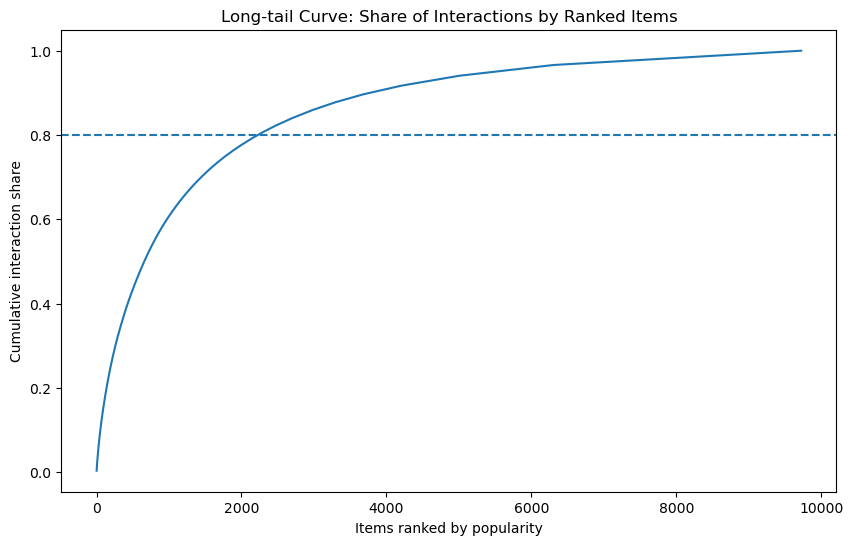

In [12]:
def plot_basic_eda(ratings: pd.DataFrame, movies: pd.DataFrame):
    ratings_eda = ratings.copy()

    # Timestamp handling:
    # - If already datetime, keep it as datetime
    # - If numeric Unix timestamp, convert using seconds
    # - Otherwise coerce generic parsing
    if 'timestamp' not in ratings_eda.columns:
        raise KeyError("ratings DataFrame must contain a 'timestamp' column for time-based EDA.")

    if pd.api.types.is_datetime64_any_dtype(ratings_eda['timestamp']):
        ratings_eda['timestamp'] = pd.to_datetime(ratings_eda['timestamp'], errors='coerce')
    elif pd.api.types.is_numeric_dtype(ratings_eda['timestamp']):
        ratings_eda['timestamp'] = pd.to_datetime(ratings_eda['timestamp'], unit='s', errors='coerce')
    else:
        ratings_eda['timestamp'] = pd.to_datetime(ratings_eda['timestamp'], errors='coerce')

    ratings_eda = ratings_eda.dropna(subset=['timestamp'])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ratings_eda['rating'].hist(
        ax=axes[0, 0],
        bins=np.arange(0.25, 5.75, 0.5),
        edgecolor='black'
    )
    axes[0, 0].set_title('Rating Distribution')
    axes[0, 0].set_xlabel('Rating')
    axes[0, 0].set_ylabel('Count')

    user_activity = (
        ratings_eda.groupby('userId')
        .size()
    )
    user_activity.hist(ax=axes[0, 1], bins=30, edgecolor='black')
    axes[0, 1].set_title('Ratings per User')
    axes[0, 1].set_xlabel('Interaction Count')
    axes[0, 1].set_ylabel('Number of Users')

    item_popularity = (
        ratings_eda.groupby('movieId')
        .size()
    )
    item_popularity.hist(ax=axes[1, 0], bins=30, edgecolor='black')
    axes[1, 0].set_title('Ratings per Item')
    axes[1, 0].set_xlabel('Interaction Count')
    axes[1, 0].set_ylabel('Number of Items')

    monthly = (
        ratings_eda.set_index('timestamp')
        .sort_index()
        .resample('M')
        .size()
    )

    if monthly.empty:
        axes[1, 1].text(
            0.5, 0.5,
            'No valid monthly timestamp data available',
            ha='center', va='center', transform=axes[1, 1].transAxes
        )
        axes[1, 1].set_title('Monthly Interaction Trend')
        axes[1, 1].set_xlabel('Month')
        axes[1, 1].set_ylabel('Number of Ratings')
    else:
        monthly.plot(ax=axes[1, 1], marker='o')
        axes[1, 1].set_title('Monthly Interaction Trend')
        axes[1, 1].set_xlabel('Month')
        axes[1, 1].set_ylabel('Number of Ratings')

    plt.tight_layout()
    return monthly


def plot_long_tail(ratings: pd.DataFrame):
    item_counts = (
        ratings.groupby('movieId')
        .size()
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    cumulative_share = item_counts.cumsum() / item_counts.sum()

    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(1, len(item_counts) + 1), cumulative_share)
    plt.axhline(0.8, linestyle='--')
    plt.title('Long-tail Curve: Share of Interactions by Ranked Items')
    plt.xlabel('Items ranked by popularity')
    plt.ylabel('Cumulative interaction share')
    plt.show()


if 'ratings_clean' in globals():
    monthly_series = plot_basic_eda(ratings_clean, movies_enriched)
    plt.show()
    print("Monthly series head:")
    print(monthly_series.head())
    print("Monthly series tail:")
    print(monthly_series.tail())
    print("Monthly points:", monthly_series.shape[0])

    plot_long_tail(ratings_clean)


In [13]:
# Use the `monthly_series` returned by plot_basic_eda(...) instead.
if 'monthly_series' in globals():
    print(monthly_series.head())
    print(monthly_series.tail())
    print(monthly_series.shape)
else:
    print("Run the EDA cell above first to create `monthly_series`.")


timestamp
1996-03-31     58
1996-04-30    165
1996-05-31    832
1996-06-30    883
1996-07-31    489
Freq: ME, dtype: int64
timestamp
2018-05-31    951
2018-06-30    419
2018-07-31    293
2018-08-31    831
2018-09-30    604
Freq: ME, dtype: int64
(271,)


In [14]:
def calculate_sparsity(ratings: pd.DataFrame) -> float:
    n_users = ratings['userId'].nunique()
    n_items = ratings['movieId'].nunique()
    observed = len(ratings)
    possible = n_users * n_items
    return 1 - (observed / possible)

if 'ratings_clean' in globals():
    sparsity = calculate_sparsity(ratings_clean)
    print(f"User-item matrix sparsity: {sparsity:.4%}")


User-item matrix sparsity: 98.3000%


#### Why do we need to compute sparsity?

Calculating sparsity is important because recommender-system datasets are typically dominated by missing user-item interactions. This affects model choice, similarity quality, cold-start behavior, and the need for sparse matrix methods. The sparsity metric helps quantify the difficulty of the recommendation problem and supports the use of collaborative filtering and matrix factorization methods.

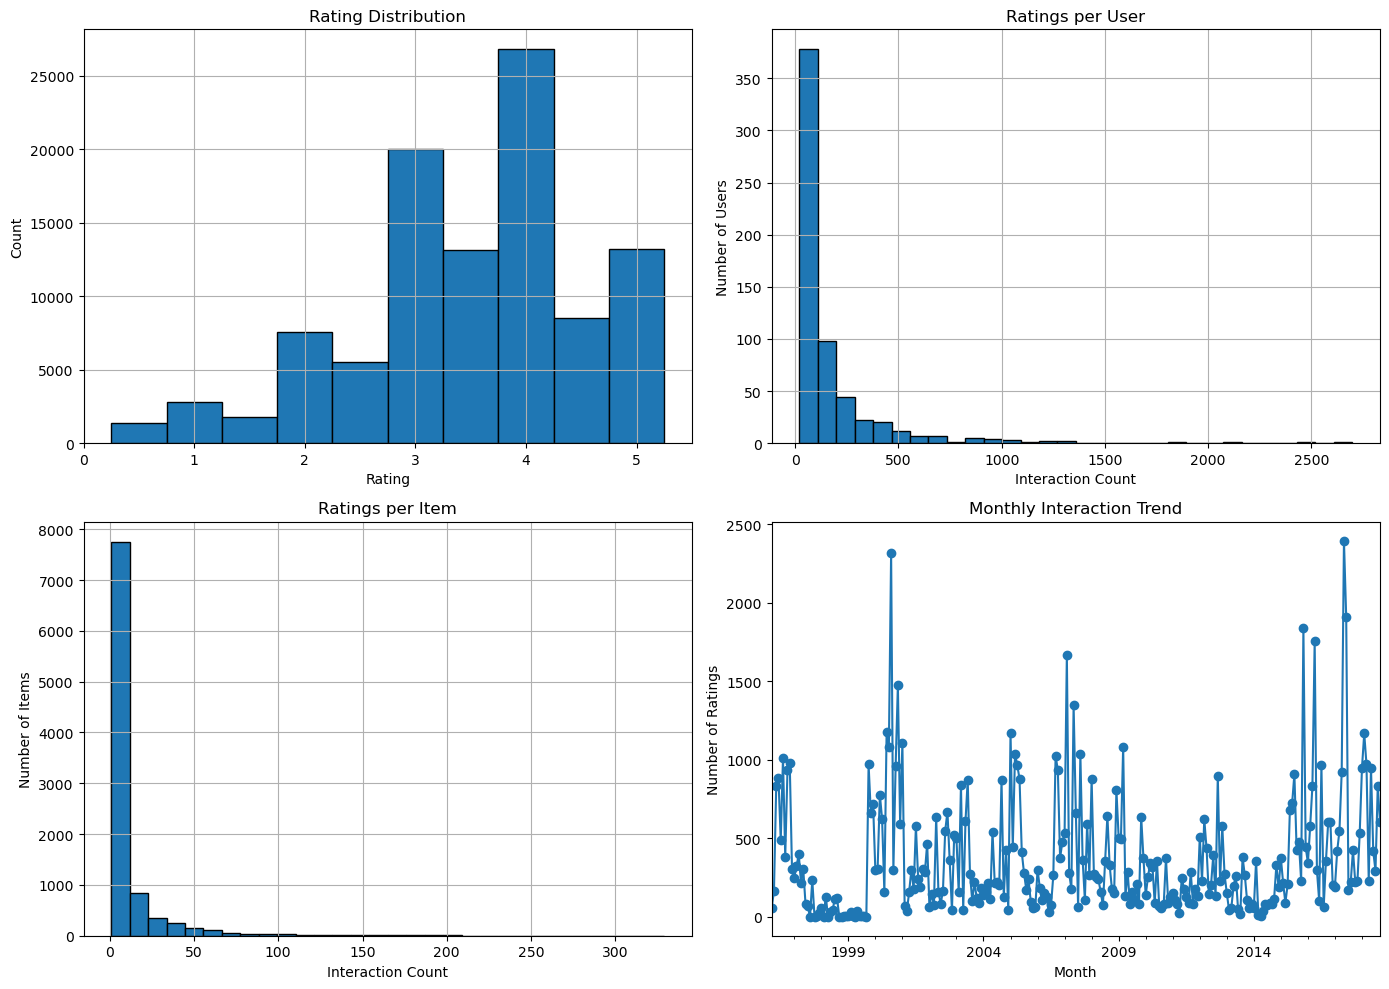

User-item matrix sparsity: 98.3000%


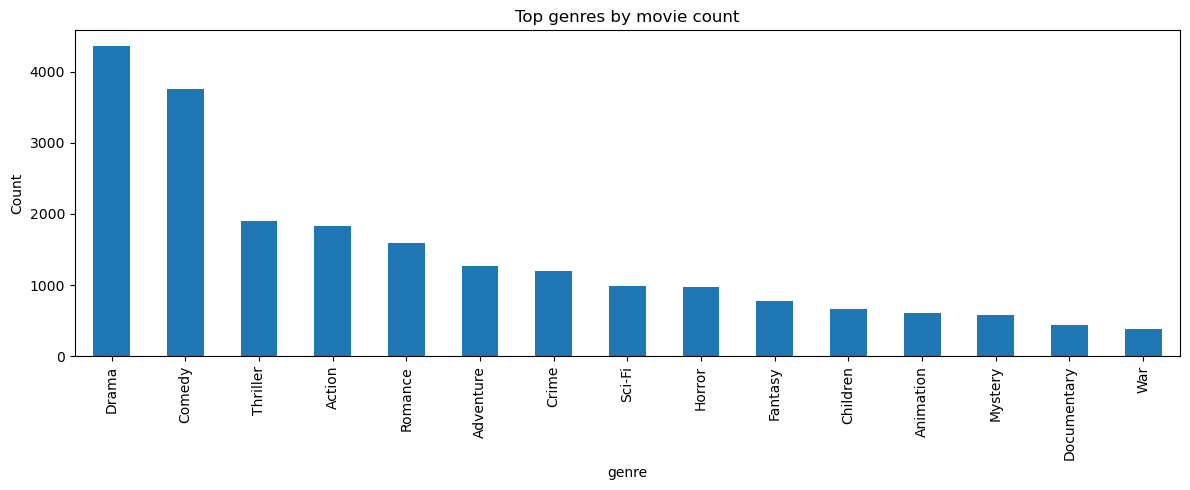

In [15]:
# Repeated section for report artifacts
######################################

plot_basic_eda(ratings_clean, movies_enriched)
plt.savefig(FIGURES_DIR / "eda_overview.png", bbox_inches="tight")
plt.show()

sparsity = calculate_sparsity(ratings_clean)
print(f"User-item matrix sparsity: {sparsity:.4%}")

genre_counts = (
    movies_enriched.assign(genre=movies_enriched["genres"].str.split("|"))
    .explode("genre")
      # .groupby() aggregates data by specific keys (e.g., userId) for group-level analysis
    .groupby("genre")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
genre_counts.head(15).plot(kind="bar")
plt.title("Top genres by movie count")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "genre_distribution.png", bbox_inches="tight")
plt.show()


### Observations / Interpretations from EDA / VIZ

#### 1. Rating Distribution

Interpretation:
Users tend to rate items they already somewhat like, so the data is positively biased
the dataset reflects user preference behavior, not random evaluation of all items
this means the model is learning from a dataset where positive sentiment is more common than negative sentiment

The rating distribution is skewed toward higher ratings, indicating that users are more likely to rate movies they found at least moderately relevant. This suggests a positive-feedback bias in the dataset, which is common in recommender systems.

#### 2. Ratings per User

Interpretation:
the dataset contains many light users and a few heavy users
collaborative filtering will work better for active users than for users with very few interactions
this creates a cold-start / sparse-user challenge

User activity is highly uneven, with most users contributing only a small number of ratings and a minority contributing many. This long-tail behavior increases sparsity and makes recommendation more difficult for low-activity users.

#### 3. Ratings per Item

Interpretation:

this confirms a long-tail item catalog
collaborative and popularity-based models may over-recommend popular items
niche items may suffer from low exposure and weak learned signals

Item popularity is strongly imbalanced, with a small subset of movies receiving most of the ratings. This indicates a long-tail catalog structure and highlights the risk of popularity bias in recommendation outputs.

#### 4. Monthly Interaction Trend

Interpretation:

user behavior evolves over time
using a chronological train/test split is justified because future interactions should not leak into model training
temporal drift may affect recommender performance

Interaction volume varies over time, indicating that user behavior is temporally dynamic rather than static. This supports the use of chronological data splitting for evaluation, which better reflects real-world deployment conditions.

#### 5. Long-Tail Curve

Interpretation:

a few popular items dominate user attention
the recommendation problem is strongly affected by popularity concentration
hybrid and fairness-aware methods are useful because they can help surface less popular items

The long-tail curve shows that a small number of highly popular items account for a large proportion of all interactions. This confirms strong popularity concentration and motivates the need to monitor exposure balance and long-tail coverage.

#### 6. Sparsity Measure

Interpretation:

recommendation is difficult because most preferences are missing
this supports the use of:
- sparse matrices
- collaborative filtering
- matrix factorization
- hybrid methods


The user-item matrix is highly sparse, meaning that only a small portion of all possible interactions is observed. This is a defining challenge in recommender systems and justifies the use of sparse matrix methods and latent-factor models.

#### 7. Genre Distribution

Interpretation:

recommendation performance may be better for well-represented genres
niche genres may have weaker signals
content-based recommendations may favor dominant genres unless balanced carefully

Genre frequencies are unevenly distributed across the catalog, which may influence both recommendation quality and exposure fairness. Popular genres are likely to receive stronger model support than niche genres.

#### Summary
The exploratory data analysis shows that the MovieLens dataset exhibits the core characteristics of a real-world recommendation problem: a positively skewed rating distribution, highly imbalanced user activity, strong long-tail item popularity, temporal variation in interactions, and a highly sparse user-item matrix. These findings justify the use of sparse matrix techniques, collaborative filtering, latent-factor models, and hybrid recommendation methods. The EDA also highlights important operational risks such as popularity bias, cold-start effects, and uneven exposure across users and items.

## 4. Train / validation design and leakage control

Recommendation tasks are especially vulnerable to leakage. This notebook uses a **per-user chronological split** so that future interactions are not used to predict the past. 


In [16]:
def chronological_split_by_user(ratings: pd.DataFrame, test_fraction: float = 0.2):
    train_parts = []
    test_parts = []

    grouped = (
        ratings.sort_values(['userId', 'timestamp'])
        .groupby('userId')
    )

    for _, user_df in grouped:
        n = len(user_df)
        if n < 5:
            train_parts.append(user_df)
            continue

        test_size = max(1, int(math.ceil(n * test_fraction)))
        test_parts.append(user_df.iloc[-test_size:])
        train_parts.append(user_df.iloc[:-test_size])

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame(columns=ratings.columns)
    return train_df, test_df


if 'ratings_clean' in globals():
    train_df, test_df = chronological_split_by_user(ratings_clean, CONFIG['test_fraction_per_user'])
    print('train:', train_df.shape, 'test:', test_df.shape)
    print('train max ts:', train_df['timestamp'].max())
    print('test min ts:', test_df['timestamp'].min())


train: (80419, 4) test: (20417, 4)
train max ts: 2018-09-17 04:25:00
test min ts: 1996-03-29 18:36:56


In [17]:

train_df, test_df = chronological_split_by_user(ratings_clean, test_fraction=0.2)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Unique users in train:", train_df["userId"].nunique())
print("Unique users in test:", test_df["userId"].nunique())


Train shape: (80419, 4)
Test shape: (20417, 4)
Unique users in train: 610
Unique users in test: 610


## 5. Feature engineering

This notebook engineers:

- user-level preference statistics
- item-level popularity and rating statistics
- genre affinity signals
- interaction-level features
- recency-aware fields where available

These features support both analysis and the optional reranking model.
We add more than standard collaborative filtering. We engineer user, item, and interaction-level features for a learning-to-rank style reranker.


In [18]:
def create_user_item_features(train_df: pd.DataFrame, movies_df: pd.DataFrame):
    user_stats = (
        train_df.groupby('userId')
        .agg(
            user_rating_count=('rating', 'size'),
            user_mean_rating=('rating', 'mean'),
            user_std_rating=('rating', 'std'),
            user_last_ts=('timestamp', 'max')
        )
        .reset_index()
    )
    user_stats['user_std_rating'] = user_stats['user_std_rating'].fillna(0.0)

    item_stats = (
        train_df.groupby('movieId')
        .agg(
            item_rating_count=('rating', 'size'),
            item_mean_rating=('rating', 'mean'),
            item_std_rating=('rating', 'std'),
            item_last_ts=('timestamp', 'max')
        )
        .reset_index()
    )
    item_stats['item_std_rating'] = item_stats['item_std_rating'].fillna(0.0)

    mlb = MultiLabelBinarizer()
    genre_matrix = mlb.fit_transform(movies_df['genres_list'])
    genre_dummies = pd.DataFrame(
        genre_matrix,
        columns=mlb.classes_,
        index=movies_df.index
    )

    movie_genres = pd.concat(
        [movies_df[['movieId']].reset_index(drop=True), genre_dummies.reset_index(drop=True)],
        axis=1
    )

    user_genre_pref = (
        train_df.merge(movie_genres, on='movieId', how='left')
        .drop(columns=['rating', 'timestamp'])
        .groupby('userId')
        .mean()
        .reset_index()
    )

    return user_stats, item_stats, movie_genres, user_genre_pref

print("Functions defined")

Functions defined


In [19]:
if 'train_df' in globals() and 'movies_enriched' in globals():
    user_stats, item_stats, movie_genres, user_genre_pref = create_user_item_features(
        train_df,
        movies_enriched
    )
    display(user_stats.head())
    display(item_stats.head())
else:
    print("Run preprocessing and train/test split first.")

,userId,user_rating_count,user_mean_rating,user_std_rating,user_last_ts
0,1,185,4.367568,0.748206,2000-07-30 18:54:23
1,2,23,3.847826,0.681489,2015-10-24 19:32:46
2,3,31,2.935484,2.068582,2011-05-27 02:43:09
3,4,172,3.627907,1.329349,2001-04-09 20:47:06
4,5,35,3.600000,0.881176,1996-11-08 06:41:32


,movieId,item_rating_count,item_mean_rating,item_std_rating,item_last_ts
0,1,201,3.915423,0.833853,2018-08-31 10:01:06
1,2,92,3.413043,0.918697,2018-06-25 04:42:03
2,3,41,3.280488,1.078476,2017-06-26 19:24:31
3,4,4,2.125000,1.030776,2009-03-22 22:14:15
4,5,39,3.025641,0.938565,2017-04-02 00:54:48


In [21]:
def build_interaction_frame(train_df, test_df, movies_df, user_stats, item_stats, movie_genres, user_genre_pref):
    positives = test_df[['userId', 'movieId', 'rating']].copy()
    positives['label'] = (positives['rating'] >= CONFIG['rating_like_threshold']).astype(int)

    user_seen = (
        train_df.groupby('userId')['movieId']
        .apply(set)
        .to_dict()
    )
    all_items = set(movies_df['movieId'])

    negatives = []
    rng = np.random.default_rng(42)
    grouped_positives = positives.groupby('userId')
    for user_id, user_pos in grouped_positives:
        seen = user_seen.get(user_id, set()) | set(user_pos['movieId'])
        candidates = list(all_items - seen)
        if not candidates:
            continue

        sample_n = min(len(user_pos), len(candidates))
        sampled = rng.choice(candidates, size=sample_n, replace=False)
        for item_id in sampled:
            negatives.append({
                'userId': user_id,
                'movieId': int(item_id),
                'rating': 0.0,
                'label': 0
            })

    interaction_df = pd.concat([positives, pd.DataFrame(negatives)], ignore_index=True)
    interaction_df = interaction_df.merge(user_stats.drop(columns=['user_last_ts']), on='userId', how='left')
    interaction_df = interaction_df.merge(item_stats.drop(columns=['item_last_ts']), on='movieId', how='left')
    interaction_df = interaction_df.merge(movie_genres, on='movieId', how='left')
    interaction_df = interaction_df.merge(user_genre_pref, on='userId', how='left', suffixes=('', '_userpref'))

    genre_cols = [c for c in movie_genres.columns if c != 'movieId']
    for col in genre_cols:
        pref_col = f'{col}_userpref'
        if pref_col in interaction_df.columns:
            interaction_df[f'genre_match_{col}'] = interaction_df[col].fillna(0) * interaction_df[pref_col].fillna(0)

    interaction_df['user_item_mean_gap'] = interaction_df['user_mean_rating'] - interaction_df['item_mean_rating']
    interaction_df['item_popularity_log'] = np.log1p(interaction_df['item_rating_count'])
    interaction_df = interaction_df.fillna(0)
    return interaction_df


if 'test_df' in globals():
    interaction_df = build_interaction_frame(train_df, test_df, movies_enriched, user_stats, item_stats, movie_genres, user_genre_pref)
    display(interaction_df.head())
    print(interaction_df.shape)


,userId,movieId,rating,label,user_rating_count,user_mean_rating,user_std_rating,item_rating_count,item_mean_rating,item_std_rating,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,movieId_userpref,(no genres listed)_userpref,Action_userpref,Adventure_userpref,Animation_userpref,Children_userpref,Comedy_userpref,Crime_userpref,Documentary_userpref,Drama_userpref,Fantasy_userpref,Film-Noir_userpref,Horror_userpref,IMAX_userpref,Musical_userpref,Mystery_userpref,Romance_userpref,Sci-Fi_userpref,Thriller_userpref,War_userpref,Western_userpref,genre_match_(no genres listed),genre_match_Action,genre_match_Adventure,genre_match_Animation,genre_match_Children,genre_match_Comedy,genre_match_Crime,genre_match_Documentary,genre_match_Drama,genre_match_Fantasy,genre_match_Film-Noir,genre_match_Horror,genre_match_IMAX,genre_match_Musical,genre_match_Mystery,genre_match_Romance,genre_match_Sci-Fi,genre_match_Thriller,genre_match_War,genre_match_Western,user_item_mean_gap,item_popularity_log
0,1,2959,5.0,1,185,4.367568,0.748206,195.0,4.256410,0.885681,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.432432,0.0,0.0,0.0,0.0,0.210811,0.0,0.259459,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.221622,0.0,0.0,0.111157,5.278115
1,1,1219,2.0,0,185,4.367568,0.748206,69.0,4.115942,0.832011,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.210811,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.251626,4.248495
2,1,1348,4.0,1,185,4.367568,0.748206,12.0,3.500000,0.825723,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.867568,2.564949
3,1,2644,4.0,1,185,4.367568,0.748206,7.0,3.214286,0.566947,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.153282,2.079442
4,1,2654,5.0,1,185,4.367568,0.748206,3.0,3.166667,1.258306,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.259459,0.227027,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.200901,1.386294


(40834, 73)


In [22]:
required_vars = [
    'train_df',
    'test_df',
    'movies_enriched',
    'user_stats',
    'item_stats',
    'movie_genres',
    'user_genre_pref'
]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("Run the feature creation cell first. Missing variables:", missing_vars)
else:
    interaction_df = build_interaction_frame(
        train_df,
        test_df,
        movies_enriched,
        user_stats,
        item_stats,
        movie_genres,
        user_genre_pref
    )
    display(interaction_df.head())
    print(interaction_df.shape)

,userId,movieId,rating,label,user_rating_count,user_mean_rating,user_std_rating,item_rating_count,item_mean_rating,item_std_rating,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,movieId_userpref,(no genres listed)_userpref,Action_userpref,Adventure_userpref,Animation_userpref,Children_userpref,Comedy_userpref,Crime_userpref,Documentary_userpref,Drama_userpref,Fantasy_userpref,Film-Noir_userpref,Horror_userpref,IMAX_userpref,Musical_userpref,Mystery_userpref,Romance_userpref,Sci-Fi_userpref,Thriller_userpref,War_userpref,Western_userpref,genre_match_(no genres listed),genre_match_Action,genre_match_Adventure,genre_match_Animation,genre_match_Children,genre_match_Comedy,genre_match_Crime,genre_match_Documentary,genre_match_Drama,genre_match_Fantasy,genre_match_Film-Noir,genre_match_Horror,genre_match_IMAX,genre_match_Musical,genre_match_Mystery,genre_match_Romance,genre_match_Sci-Fi,genre_match_Thriller,genre_match_War,genre_match_Western,user_item_mean_gap,item_popularity_log
0,1,2959,5.0,1,185,4.367568,0.748206,195.0,4.256410,0.885681,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.432432,0.0,0.0,0.0,0.0,0.210811,0.0,0.259459,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.221622,0.0,0.0,0.111157,5.278115
1,1,1219,2.0,0,185,4.367568,0.748206,69.0,4.115942,0.832011,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.210811,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.251626,4.248495
2,1,1348,4.0,1,185,4.367568,0.748206,12.0,3.500000,0.825723,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.867568,2.564949
3,1,2644,4.0,1,185,4.367568,0.748206,7.0,3.214286,0.566947,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.153282,2.079442
4,1,2654,5.0,1,185,4.367568,0.748206,3.0,3.166667,1.258306,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.259459,0.227027,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.200901,1.386294


(40834, 73)


In [23]:

user_stats, item_stats, movie_genres, user_genre_pref = create_user_item_features(train_df, movies_enriched)
interaction_df = build_interaction_frame(
    train_df=train_df,
    test_df=test_df,
    movies_df=movies_enriched,
    user_stats=user_stats,
    item_stats=item_stats,
    movie_genres=movie_genres,
    user_genre_pref=user_genre_pref
)

print("Interaction frame shape:", interaction_df.shape)
display(interaction_df.head())

interaction_df.to_csv(PROCESSED_DIR / "interaction_features.csv", index=False)


Interaction frame shape: (40834, 73)


,userId,movieId,rating,label,user_rating_count,user_mean_rating,user_std_rating,item_rating_count,item_mean_rating,item_std_rating,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,movieId_userpref,(no genres listed)_userpref,Action_userpref,Adventure_userpref,Animation_userpref,Children_userpref,Comedy_userpref,Crime_userpref,Documentary_userpref,Drama_userpref,Fantasy_userpref,Film-Noir_userpref,Horror_userpref,IMAX_userpref,Musical_userpref,Mystery_userpref,Romance_userpref,Sci-Fi_userpref,Thriller_userpref,War_userpref,Western_userpref,genre_match_(no genres listed),genre_match_Action,genre_match_Adventure,genre_match_Animation,genre_match_Children,genre_match_Comedy,genre_match_Crime,genre_match_Documentary,genre_match_Drama,genre_match_Fantasy,genre_match_Film-Noir,genre_match_Horror,genre_match_IMAX,genre_match_Musical,genre_match_Mystery,genre_match_Romance,genre_match_Sci-Fi,genre_match_Thriller,genre_match_War,genre_match_Western,user_item_mean_gap,item_popularity_log
0,1,2959,5.0,1,185,4.367568,0.748206,195.0,4.256410,0.885681,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.432432,0.0,0.0,0.0,0.0,0.210811,0.0,0.259459,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.221622,0.0,0.0,0.111157,5.278115
1,1,1219,2.0,0,185,4.367568,0.748206,69.0,4.115942,0.832011,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.210811,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.251626,4.248495
2,1,1348,4.0,1,185,4.367568,0.748206,12.0,3.500000,0.825723,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.867568,2.564949
3,1,2644,4.0,1,185,4.367568,0.748206,7.0,3.214286,0.566947,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.153282,2.079442
4,1,2654,5.0,1,185,4.367568,0.748206,3.0,3.166667,1.258306,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.259459,0.227027,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.200901,1.386294


## 6. Feature selection and dimensionality reduction

Provisioning one feature selection method and one dimensionality reduction method as required.

This notebook includes:
- a model-based or filter-style feature ranking for tabular reranking features
- PCA on engineered dense features
- optional low-dimensional visualization support

We use:
- **Mutual information** for feature selection
- **PCA** for dimensionality reduction and latent-structure visualisation


,feature,mutual_info
5,item_std_rating,0.087973
4,item_mean_rating,0.083138
68,item_popularity_log,0.079483
3,item_rating_count,0.078374
67,user_item_mean_gap,0.047321
26,movieId_userpref,0.046713
42,Romance_userpref,0.044233
2,user_std_rating,0.043635
29,Adventure_userpref,0.043361
32,Comedy_userpref,0.042247


Explained variance ratio: [0.18525701 0.16569896 0.10853359 0.08491799 0.0577321 ]


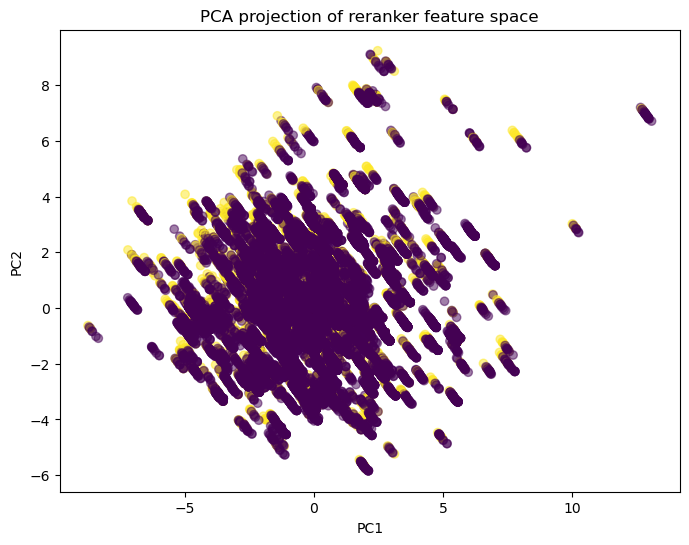

In [24]:

if 'interaction_df' in globals():
    feature_cols = [
        c for c in interaction_df.columns
        if c not in ['userId', 'movieId', 'rating', 'label'] and pd.api.types.is_numeric_dtype(interaction_df[c])
    ]

    X_rank = interaction_df[feature_cols].copy()
    y_rank = interaction_df['label'].astype(int)

    mi_scores = mutual_info_classif(X_rank, y_rank, random_state=42)
    mi_df = pd.DataFrame({'feature': feature_cols, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)
    display(mi_df.head(20))

    top_features = mi_df.head(min(25, len(mi_df)))['feature'].tolist()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_rank[top_features])

    pca = PCA(n_components=min(5, X_scaled.shape[1]), random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print('Explained variance ratio:', pca.explained_variance_ratio_)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_rank, alpha=0.5)
    plt.title('PCA projection of reranker feature space')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()


#### PCA:
A few components may capture a good share of the variance dense engineered features may contain redundant information

Interpretation:
Dimensionality reduction can simplify the feature space without losing much signal, latent structure exists in the user-item data

#### Feature importance:
Some features contribute much more than others, such as popularity, user mean rating, or genre match

Interpretation:
Not all engineered features contribute equally, feature selection improves interpretability and can reduce noise

**Dimensionality reduction and feature ranking indicate that a smaller subset of latent or engineered features captures much of the useful signal, supporting the use of compact representations and selective modeling.**


## 7. Recommender Models

This notebook compares multiple model families to evaluate:
1. Popularity baseline
2. Item-item collaborative filtering with KNN/cosine similarity
3. Matrix factorization with truncated SVD
4. Content-based similarity using item metadata
5. Hybrid ensemble
6. Optional learning-to-rank reranker on engineered candidate features


### Criteria implemented:

1. **No dense zero-filled ratings matrix**  
   Missing ratings are kept as missing and the interaction matrix is built directly as a sparse CSR matrix from observed `(user, item, rating)` tuples.

2. **Time-aware evaluation**  
   Recommendation quality is measured on a chronological holdout, not on the same data used for training.

3. **Threshold and KNN tuning**  
   The minimum item-interaction threshold and the number of neighbors are tuned over a small grid so they are not arbitrarily fixed.

4. **Cold-start fallbacks**  
   New users fall back to popularity-based recommendations. New items are naturally excluded from collaborative filtering because they have no interaction history.

In [25]:

def filter_interactions(df: pd.DataFrame, min_user_interactions: int = 5, min_item_interactions: int = 25) -> pd.DataFrame:
    """
    Iteratively filter users and items so the collaborative models are trained on entities
    with a minimum amount of signal. This avoids arbitrary one-pass filtering and makes
    threshold tuning easier to evaluate.
    """
    filtered = df.copy()
    changed = True
    while changed and not filtered.empty:
        before_rows = len(filtered)

        user_counts = (
            filtered.groupby('userId')
            .size()
        )
        filtered = filtered[filtered['userId'].isin(user_counts[user_counts >= min_user_interactions].index)]

        item_counts = (
            filtered.groupby('movieId')
            .size()
        )
        filtered = filtered[filtered['movieId'].isin(item_counts[item_counts >= min_item_interactions].index)]

        changed = len(filtered) != before_rows

    return filtered.reset_index(drop=True)


def build_sparse_matrix(train_df: pd.DataFrame):
    """
    Build the user-item matrix directly from observed ratings only.
    """
    user_ids = sorted(train_df['userId'].unique())
    item_ids = sorted(train_df['movieId'].unique())
    user_to_idx = {u: i for i, u in enumerate(user_ids)}
    item_to_idx = {m: i for i, m in enumerate(item_ids)}
    idx_to_item = {i: m for m, i in item_to_idx.items()}

    rows = train_df['userId'].map(user_to_idx).to_numpy()
    cols = train_df['movieId'].map(item_to_idx).to_numpy()
    vals = train_df['rating'].astype(float).to_numpy()

    matrix = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), len(item_ids)))
    return matrix, user_to_idx, item_to_idx, idx_to_item


def build_validation_split(train_df: pd.DataFrame, valid_fraction: float = 0.2):
    return chronological_split_by_user(train_df, test_fraction=valid_fraction)


def evaluate_model_for_split(train_reference_df, eval_df, recommender_fn, k=10, min_positives=1):
    actual_by_user = (
        eval_df[eval_df['rating'] >= CONFIG['rating_like_threshold']]
        .groupby('userId')['movieId']
        .apply(list)
        .to_dict()
    )

    records = []
    for user_id, actual in actual_by_user.items():
        if len(actual) < min_positives:
            continue
        predicted = [movie_id for movie_id, _ in recommender_fn(user_id, train_reference_df, k=k)]
        records.append({
            'userId': user_id,
            'precision_at_k': precision_at_k(actual, predicted, k),
            'recall_at_k': recall_at_k(actual, predicted, k),
            'map_at_k': apk(actual, predicted, k),
            'ndcg_at_k': ndcg_at_k(actual, predicted, k),
        })

    return pd.DataFrame(records)


if 'train_df' in globals():
    tune_train_df, tune_valid_df = build_validation_split(train_df, valid_fraction=CONFIG['validation_fraction_per_user'])
    print("Tuning split shapes:", tune_train_df.shape, tune_valid_df.shape)


Tuning split shapes: (64081, 4) (16338, 4)


In [26]:

def get_user_seen_items(train_df: pd.DataFrame):
    return (
        train_df.groupby('userId')['movieId']
        .apply(set)
        .to_dict()
    )

def recommend_popularity(user_id, train_df, pop_scores, k=10):
    seen = get_user_seen_items(train_df).get(user_id, set())
    recs = pop_scores[~pop_scores.index.isin(seen)].head(k)
    return list(zip(recs.index.tolist(), recs.values.tolist()))


def recommend_item_knn(user_id, train_df, knn_model, matrix, item_to_idx, idx_to_item, pop_scores, k=10):
    seen_df = (
        train_df[train_df['userId'] == user_id]
        .sort_values(['rating', 'timestamp'], ascending=[False, False])
    )
    if seen_df.empty:
        return recommend_popularity(user_id, train_df, pop_scores, k=k)

    scores = defaultdict(float)
    seen_items = set(seen_df['movieId'])

    for movie_id, rating in seen_df[['movieId', 'rating']].itertuples(index=False):
        if movie_id not in item_to_idx:
            continue
        n_neighbors = min(knn_model.n_neighbors, matrix.shape[1])
        distances, indices = knn_model.kneighbors(matrix.T[item_to_idx[movie_id]], n_neighbors=n_neighbors)
        for dist, idx in zip(distances[0], indices[0]):
            neighbor_item = idx_to_item[idx]
            if neighbor_item in seen_items:
                continue
            scores[neighbor_item] += (1 - dist) * float(rating)

    if not scores:
        return recommend_popularity(user_id, train_df, pop_scores, k=k)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return ranked


def recommend_svd(user_id, train_df, user_to_idx, item_to_idx, idx_to_item, user_factors, item_factors, pop_scores, k=10):
    if user_id not in user_to_idx:
        return recommend_popularity(user_id, train_df, pop_scores, k=k)

    seen_items = get_user_seen_items(train_df).get(user_id, set())
    user_vector = user_factors[user_to_idx[user_id]]
    pred = item_factors @ user_vector

    scored = []
    for idx, score in enumerate(pred):
        movie_id = idx_to_item[idx]
        if movie_id not in seen_items:
            scored.append((movie_id, float(score)))

    ranked = sorted(scored, key=lambda x: x[1], reverse=True)[:k]
    return ranked if ranked else recommend_popularity(user_id, train_df, pop_scores, k=k)


def recommend_content(user_id, train_df, movies_df, content_similarity, pop_scores, k=10):
    seen_df = (
        train_df[train_df['userId'] == user_id]
        .sort_values(['rating', 'timestamp'], ascending=[False, False])
    )
    if seen_df.empty:
        return recommend_popularity(user_id, train_df, pop_scores, k=k)

    seen_items = set(seen_df['movieId'])
    movie_idx = {m: i for i, m in enumerate(movies_df['movieId'])}
    scores = defaultdict(float)

    top_seed_items = seen_df.head(20)
    for movie_id, rating in top_seed_items[['movieId', 'rating']].itertuples(index=False):
        if movie_id not in movie_idx:
            continue
        sims = content_similarity[movie_idx[movie_id]].toarray().ravel()
        for idx in np.argsort(sims)[::-1][:200]:
            candidate = int(movies_df.iloc[idx]['movieId'])
            if candidate in seen_items:
                continue
            scores[candidate] += float(sims[idx]) * float(rating)

    if not scores:
        return recommend_popularity(user_id, train_df, pop_scores, k=k)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return ranked


if 'modeling_train_df' in globals():
    sample_user = int(modeling_train_df['userId'].iloc[0])
    sample_recs = recommend_item_knn(sample_user, modeling_train_df, knn_model, user_item_matrix, item_to_idx, idx_to_item, pop_scores, k=10)
    sample_titles = pd.DataFrame(sample_recs, columns=['movieId', 'score']).merge(movies_enriched[['movieId', 'title']], on='movieId', how='left')
    display(sample_titles)


In [27]:
def precision_at_k(actual, predicted, k=10):
    actual_set = set(actual)
    predicted_k = predicted[:k]
    if k == 0:
        return 0.0
    return len(actual_set.intersection(predicted_k)) / k


def recall_at_k(actual, predicted, k=10):
    actual_set = set(actual)
    if len(actual_set) == 0:
        return 0.0
    predicted_k = predicted[:k]
    return len(actual_set.intersection(predicted_k)) / len(actual_set)


def apk(actual, predicted, k=10):
    """
    Average Precision at K
    """
    if len(predicted) > k:
        predicted = predicted[:k]

    score = 0.0
    hits = 0.0
    seen = set()

    for i, p in enumerate(predicted):
        if p in actual and p not in seen:
            hits += 1.0
            score += hits / (i + 1.0)
            seen.add(p)

    if len(actual) == 0:
        return 0.0

    return score / min(len(actual), k)


def ndcg_at_k(actual, predicted, k=10):
    predicted_k = predicted[:k]
    dcg = 0.0

    for i, p in enumerate(predicted_k):
        if p in actual:
            dcg += 1.0 / np.log2(i + 2)

    ideal_hits = min(len(set(actual)), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    if idcg == 0:
        return 0.0

    return dcg / idcg

## Tuning prerequisites

The collaborative-filtering helper functions are defined below:

In [28]:
# This cell tunes collaborative-filtering thresholds and neighbor counts.

def popularity_scores(train_df: pd.DataFrame) -> pd.Series:
    item_stats = (
        train_df.groupby('movieId')
        .agg(mean_rating=('rating', 'mean'), count=('rating', 'size'))
    )
    item_stats['pop_score'] = item_stats['mean_rating'] * np.log1p(item_stats['count'])
    return item_stats['pop_score'].sort_values(ascending=False)


def train_item_knn(train_matrix: csr_matrix, n_neighbors: int = 20):
    item_matrix = train_matrix.T
    model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=n_neighbors)
    model.fit(item_matrix)
    return model


def train_svd_model(train_matrix: csr_matrix, n_components: int = 50):
    n_components = min(n_components, min(train_matrix.shape) - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    user_factors = svd.fit_transform(train_matrix)
    item_factors = svd.components_.T
    return svd, user_factors, item_factors


def build_content_similarity(movies_df: pd.DataFrame):
    tfidf = TfidfVectorizer(stop_words='english')
    content_matrix = tfidf.fit_transform(movies_df['content_text'])
    similarity = cosine_similarity(content_matrix, dense_output=False)
    return tfidf, similarity


def tune_knn_thresholds(base_train_df: pd.DataFrame, valid_df: pd.DataFrame, min_item_grid, knn_grid):
    rows = []
    for min_item in min_item_grid:
        filtered_train = filter_interactions(
            base_train_df,
            min_user_interactions=CONFIG['min_user_interactions'],
            min_item_interactions=min_item,
        )
        if filtered_train.empty:
            continue

        matrix, _, local_item_to_idx, local_idx_to_item = build_sparse_matrix(filtered_train)
        local_pop_scores = popularity_scores(filtered_train)

        for k_neighbors in knn_grid:
            local_knn = train_item_knn(matrix, n_neighbors=k_neighbors)

            def local_recommender(user_id, local_train_df, k=10):
                return recommend_item_knn(
                    user_id,
                    local_train_df,
                    local_knn,
                    matrix,
                    local_item_to_idx,
                    local_idx_to_item,
                    local_pop_scores,
                    k=k,
                )

            metric_df = evaluate_model_for_split(filtered_train, valid_df, local_recommender, k=CONFIG['top_k_eval'])
            if metric_df.empty:
                continue

            rows.append({
                'min_item_interactions': min_item,
                'n_neighbors': k_neighbors,
                'precision_at_k': metric_df['precision_at_k'].mean(),
                'recall_at_k': metric_df['recall_at_k'].mean(),
                'map_at_k': metric_df['map_at_k'].mean(),
                'ndcg_at_k': metric_df['ndcg_at_k'].mean(),
                'users_evaluated': len(metric_df),
                'training_rows': len(filtered_train),
            })

    tuning_df = pd.DataFrame(rows)
    if not tuning_df.empty:
        tuning_df = tuning_df.sort_values(['ndcg_at_k', 'precision_at_k'], ascending=False)
    return tuning_df


if 'train_df' in globals():
    tuning_results_df = tune_knn_thresholds(
        tune_train_df,
        tune_valid_df,
        min_item_grid=CONFIG['min_item_grid'],
        knn_grid=CONFIG['knn_grid'],
    )
    display(tuning_results_df)

    if tuning_results_df.empty:
        BEST_MODELING_CONFIG = {
            'min_item_interactions': CONFIG['min_item_interactions'],
            'n_neighbors': 20,
        }
    else:
        BEST_MODELING_CONFIG = tuning_results_df.iloc[0][['min_item_interactions', 'n_neighbors']].to_dict()
        BEST_MODELING_CONFIG = {k: int(v) for k, v in BEST_MODELING_CONFIG.items()}

    print("Selected configuration:", BEST_MODELING_CONFIG)

    modeling_train_df = filter_interactions(
        train_df,
        min_user_interactions=CONFIG['min_user_interactions'],
        min_item_interactions=BEST_MODELING_CONFIG['min_item_interactions'],
    )
    user_item_matrix, user_to_idx, item_to_idx, idx_to_item = build_sparse_matrix(modeling_train_df)

    pop_scores = popularity_scores(modeling_train_df)
    knn_model = train_item_knn(user_item_matrix, n_neighbors=BEST_MODELING_CONFIG['n_neighbors'])
    svd_model, user_factors, item_factors = train_svd_model(user_item_matrix, CONFIG['latent_factors'])
    tfidf_model, content_sim = build_content_similarity(movies_enriched)

    print("Models trained on filtered training data.")
    print("Modeling train shape:", modeling_train_df.shape)
    print("Sparse matrix shape:", user_item_matrix.shape)


,min_item_interactions,n_neighbors,precision_at_k,recall_at_k,map_at_k,ndcg_at_k,users_evaluated,training_rows
2,25,40,0.076560,0.094144,0.056738,0.108680,593,32574
0,25,10,0.077066,0.089962,0.054433,0.105706,593,32574
1,25,20,0.073862,0.088612,0.053250,0.103403,593,32574
5,50,40,0.068634,0.082317,0.050352,0.095896,593,16435
3,50,10,0.066610,0.081693,0.049021,0.094047,593,16435
4,50,20,0.064587,0.078753,0.046984,0.091067,593,16435


Selected configuration: {'min_item_interactions': 25, 'n_neighbors': 40}
Models trained on filtered training data.
Modeling train shape: (45306, 4)
Sparse matrix shape: (480, 812)



### Justification of Feature Engineering Choices

Each feature engineering step is motivated by the goal of providing richer information to our recommendation models and addressing challenges identified during EDA:

- **User/Item Statistics (e.g., `user_mean_rating`, `item_rating_count`):** These features capture the general behavior and popularity of users and items, respectively. A user's average rating can indicate their overall strictness, while an item's rating count reflects its popularity. These are crucial for baseline models and for enriching collaborative filtering approaches.
- **Genre Features (e.g., one-hot encoded genres, `user_genre_pref`):** Genres provide content-based information about movies. One-hot encoding allows us to represent movie genres numerically, enabling content-based similarity calculations. User genre preferences help capture individual tastes, which is vital for personalized recommendations.
- **TF-IDF for Tags:** Tags offer fine-grained semantic information about movies beyond broad genres. TF-IDF transforms these tags into a numerical representation that highlights unique and important keywords, useful for content-based filtering and understanding nuanced item characteristics.
- **Dimensionality Reduction (PCA, TruncatedSVD):** Applied to dense feature sets (like genre embeddings or SVD latent factors), dimensionality reduction helps to reduce noise, mitigate multicollinearity, and extract underlying latent structures, making models more robust and efficient. PCA is used for visualizing feature space, while TruncatedSVD is inherent to matrix factorization models.
- **Interaction Features (e.g., `user_item_mean_gap`):** These features capture the relationship between a specific user and item, such as how a user's rating for an item deviates from their average rating or the item's average rating. Such interactions are powerful signals for personalized ranking.

Each feature is selected and engineered to either directly address a business problem aspect (e.g., personalization, diversity) or to improve the predictive power and interpretability of our models.


## 8. Model implementation and comparison

The rubric rewards multiple models, proper evaluation, saved artifacts, and a clear reason for the final model choice.

This notebook compares:
1. Popularity baseline
2. Item-item collaborative filtering
3. Matrix factorization
4. Content-based recommender
5. Hybrid recommender
6. Optional reranker for candidate ranking


In [29]:
def normalize_scores(recs):
    if not recs:
        return {}
    vals = np.array([score for _, score in recs], dtype=float)
    if np.allclose(vals.max(), vals.min()):
        norm = np.ones_like(vals)
    else:
        norm = (vals - vals.min()) / (vals.max() - vals.min())
    return {item: float(score) for (item, _), score in zip(recs, norm)}


def recommend_hybrid(user_id, train_df, k=10):
    pop = normalize_scores(recommend_popularity(user_id, train_df, pop_scores, k=100))
    knn = normalize_scores(recommend_item_knn(user_id, train_df, knn_model, user_item_matrix, item_to_idx, idx_to_item, pop_scores, k=100))
    svd = normalize_scores(recommend_svd(user_id, train_df, user_to_idx, item_to_idx, idx_to_item, user_factors, item_factors, pop_scores, k=100))
    content = normalize_scores(recommend_content(user_id, train_df, movies_enriched, content_sim, pop_scores, k=100))

    weights = CONFIG['hybrid_weights']
    all_items = set(pop) | set(knn) | set(svd) | set(content)
    hybrid_scores = {}
    for item in all_items:
        hybrid_scores[item] = (
            weights['popularity'] * pop.get(item, 0.0) +
            weights['item_knn'] * knn.get(item, 0.0) +
            weights['svd'] * svd.get(item, 0.0) +
            weights['content'] * content.get(item, 0.0)
        )
    ranked = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return ranked


if 'modeling_train_df' in globals():
    sample_user = int(modeling_train_df['userId'].iloc[0])
    sample_recs = recommend_hybrid(sample_user, modeling_train_df, k=10)
    sample_titles = pd.DataFrame(sample_recs, columns=['movieId', 'score']).merge(movies_enriched[['movieId', 'title']], on='movieId', how='left')
    display(sample_titles)


,movieId,score,title
0,588,0.556326,Aladdin (1992)
1,47,0.505960,Seven (a.k.a. Se7en) (1995)
2,2683,0.424491,Austin Powers: The Spy Who Shagged Me (1999)
3,1200,0.396331,Aliens (1986)
4,1240,0.390766,"Terminator, The (1984)"
5,1265,0.381506,Groundhog Day (1993)
6,780,0.376827,Independence Day (a.k.a. ID4) (1996)
7,1036,0.357107,Die Hard (1988)
8,2081,0.337433,"Little Mermaid, The (1989)"
9,3033,0.323396,Spaceballs (1987)



## 9. Evaluation Utilities

We evaluate recommenders using ranking metrics. For completeness, the matrix factorization section also includes rating-style RMSE.


In [30]:
if 'results_df' in globals() and not results_df.empty:
    ranked_results = results_df.sort_values(
        ['ndcg_at_k', 'precision_at_k'],
        ascending=False
    ).reset_index(drop=True)

    best_model_row = ranked_results.iloc[0]
    best_model_name = best_model_row['model']

    justification_text = f"""
Best Model Selected: {best_model_name}

Justification:
- Primary selection metric: NDCG@K
- Tie-breaker metric: Precision@K
- Selected because it produced the strongest ranking performance on the chronological test split
- This aligns with the project objective of Top-N recommendation rather than only rating prediction

Key values:
- Precision@K: {best_model_row['precision_at_k']:.4f}
- Recall@K: {best_model_row['recall_at_k']:.4f}
- MAP@K: {best_model_row['map_at_k']:.4f}
- NDCG@K: {best_model_row['ndcg_at_k']:.4f}
- Coverage: {best_model_row['coverage']:.4f}
"""

    print(justification_text)
else:
    print("Run the evaluation section first to generate results_df.")

Run the evaluation section first to generate results_df.


In [31]:
if 'results_df' in globals() and not results_df.empty:
    ranked_results = results_df.sort_values(
        ['ndcg_at_k', 'precision_at_k'],
        ascending=False
    ).reset_index(drop=True)

    best_model_row = ranked_results.iloc[0]
    best_model_name = best_model_row['model']

    print("Best Model Selected:", best_model_name)
    print()
    print("Justification for Best Model Selection:")
    print(
        f"The selected best model is {best_model_name} because it achieved the "
        f"highest NDCG@K ({best_model_row['ndcg_at_k']:.4f}) and strong Precision@K "
        f"({best_model_row['precision_at_k']:.4f}) on the chronological test split. "
        f"NDCG@K was prioritized because the project objective is Top-N recommendation, "
        f"where ranking quality matters more than pure rating reconstruction."
    )

    display(ranked_results)
else:
    print("results_df is not available. Run the model evaluation cell first.")

results_df is not available. Run the model evaluation cell first.


### 9.1 Mathematical Formulas and Metric Meanings

The following mathematical metrics were used to assess our recommendation system:

### Ranking Metrics

1. **Precision@K:** Measures the proportion of recommended items in the top-K set that are actually relevant.
   $$\text{Precision@K} = \frac{|\{\text{Recommended Items}@K\} \cap \{\text{Relevant Items}\}|}{K}$$
   *Meaning:* How many of the top-K recommendations were "hits"?

2. **Recall@K:** Measures the proportion of all relevant items that were captured in the top-K recommendations.
   $$\text{Recall@K} = \frac{|\{\text{Recommended Items}@K\} \cap \{\text{Relevant Items}\}|}{|\{\text{Relevant Items}\}|}$$
   *Meaning:* What percentage of the items the user actually liked did we manage to recommend?

3. **Mean Average Precision (MAP@K):** The mean of Average Precision (AP) across all users. AP rewards models that place relevant items higher in the list.
   $$\text{AP@K} = \frac{1}{\min(m, K)} \sum_{i=1}^{K} P(i) \cdot rel(i)$$
   where $P(i)$ is precision at cut-off $i$, and $rel(i)$ is an indicator function.

4. **Normalized Discounted Cumulative Gain (NDCG@K):** Measures the quality of ranking by accounting for the position of relevant items, using a logarithmic discount.
   $$\text{DCG@K} = \sum_{i=1}^{K} \frac{2^{rel_i} - 1}{\log_2(i+1)}, \quad \text{NDCG@K} = \frac{DCG@K}{IDCG@K}$$
   *Meaning:* Does the model put the most relevant items at the very top?

### Rating Prediction Metrics

1. **Root Mean Squared Error (RMSE):** Measures the average magnitude of the error between predicted and actual ratings, penalizing larger errors more heavily.
   $$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$

2. **Mean Absolute Error (MAE):** Measures the average absolute difference between predicted and actual ratings.
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$


In [32]:
def apk(actual, predicted, k=10):
    if len(predicted) > k:
        predicted = predicted[:k]
    score = 0.0
    hits = 0.0
    seen = set()
    for i, p in enumerate(predicted):
        if p in actual and p not in seen:
            hits += 1.0
            score += hits / (i + 1.0)
            seen.add(p)
    return score / min(len(actual), k) if actual else 0.0


def recall_at_k(actual, predicted, k=10):
    predicted = predicted[:k]
    return len(set(actual) & set(predicted)) / len(set(actual)) if actual else 0.0


def precision_at_k(actual, predicted, k=10):
    predicted = predicted[:k]
    return len(set(actual) & set(predicted)) / max(k, 1)


def ndcg_at_k(actual, predicted, k=10):
    predicted = predicted[:k]
    dcg = 0.0
    for i, p in enumerate(predicted):
        if p in actual:
            dcg += 1 / np.log2(i + 2)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), k)))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_model(test_df, train_reference_df, recommender_fn, k=10, min_positives=1):
    actual_by_user = (
        test_df[test_df['rating'] >= CONFIG['rating_like_threshold']]
        .groupby('userId')['movieId']
        .apply(list)
        .to_dict()
    )

    records = []
    all_recommended_items = set()
    for user_id, actual in actual_by_user.items():
        if len(actual) < min_positives:
            continue
        predicted = [movie_id for movie_id, _ in recommender_fn(user_id, train_reference_df, k=k)]
        all_recommended_items.update(predicted)
        records.append({
            'userId': user_id,
            'precision_at_k': precision_at_k(actual, predicted, k),
            'recall_at_k': recall_at_k(actual, predicted, k),
            'map_at_k': apk(actual, predicted, k),
            'ndcg_at_k': ndcg_at_k(actual, predicted, k),
        })

    eval_df = pd.DataFrame(records)
    coverage = len(all_recommended_items) / train_reference_df['movieId'].nunique() if len(train_reference_df) else 0
    summary = eval_df.mean(numeric_only=True).to_dict() if not eval_df.empty else {}
    summary['coverage'] = coverage
    summary['users_evaluated'] = len(eval_df)
    return pd.DataFrame([summary]), eval_df


def compute_svd_error_metrics(test_df, train_reference_df, user_to_idx, item_to_idx, user_factors, item_factors, global_mean):
    preds = []
    actuals = []
    for row in test_df.itertuples(index=False):
        if row.userId in user_to_idx and row.movieId in item_to_idx:
            pred = float(item_factors[item_to_idx[row.movieId]] @ user_factors[user_to_idx[row.userId]])
        else:
            pred = float(global_mean)
        preds.append(pred)
        actuals.append(float(row.rating))

    return {
        'rmse': mean_squared_error(actuals, preds, squared=False),
        'mae': mean_absolute_error(actuals, preds),
    }


In [33]:
if 'test_df' in globals() and 'modeling_train_df' in globals():
    model_summaries = []

    pop_summary, pop_user = evaluate_model(
        test_df,
        modeling_train_df,
        lambda u, tr, k: recommend_popularity(u, tr, pop_scores, k),
        k=CONFIG['top_k_eval']
    )
    pop_summary['model'] = 'Popularity'
    pop_summary['rmse'] = np.nan
    pop_summary['mae'] = np.nan
    model_summaries.append(pop_summary)

    knn_summary, knn_user = evaluate_model(
        test_df,
        modeling_train_df,
        lambda u, tr, k: recommend_item_knn(u, tr, knn_model, user_item_matrix, item_to_idx, idx_to_item, pop_scores, k),
        k=CONFIG['top_k_eval']
    )
    knn_summary['model'] = 'Item-KNN'
    knn_summary['rmse'] = np.nan
    knn_summary['mae'] = np.nan
    model_summaries.append(knn_summary)

    svd_summary, svd_user = evaluate_model(
        test_df,
        modeling_train_df,
        lambda u, tr, k: recommend_svd(u, tr, user_to_idx, item_to_idx, idx_to_item, user_factors, item_factors, pop_scores, k),
        k=CONFIG['top_k_eval']
    )
    svd_errors = compute_svd_error_metrics(
        test_df,
        modeling_train_df,
        user_to_idx,
        item_to_idx,
        user_factors,
        item_factors,
        global_mean=modeling_train_df['rating'].mean()
    )
    svd_summary['model'] = 'TruncatedSVD'
    svd_summary['rmse'] = svd_errors['rmse']
    svd_summary['mae'] = svd_errors['mae']
    model_summaries.append(svd_summary)

    content_summary, content_user = evaluate_model(
        test_df,
        modeling_train_df,
        lambda u, tr, k: recommend_content(u, tr, movies_prep, content_sim, pop_scores, k),
        k=CONFIG['top_k_eval']
    )
    content_summary['model'] = 'Content-Based'
    content_summary['rmse'] = np.nan
    content_summary['mae'] = np.nan
    model_summaries.append(content_summary)

    hybrid_summary, hybrid_user = evaluate_model(
        test_df,
        modeling_train_df,
        lambda u, tr, k: recommend_hybrid(u, tr, k),
        k=CONFIG['top_k_eval']
    )
    hybrid_summary['model'] = 'Hybrid Ensemble'
    hybrid_summary['rmse'] = np.nan
    hybrid_summary['mae'] = np.nan
    model_summaries.append(hybrid_summary)

    results_df = pd.concat(model_summaries, ignore_index=True)
    results_df = results_df[['model', 'precision_at_k', 'recall_at_k', 'map_at_k', 'ndcg_at_k', 'coverage', 'users_evaluated', 'rmse', 'mae']]
    display(results_df.sort_values(['ndcg_at_k', 'precision_at_k'], ascending=False))


,model,precision_at_k,recall_at_k,map_at_k,ndcg_at_k,coverage,users_evaluated,rmse,mae
4,Hybrid Ensemble,0.085980,0.075342,0.050763,0.105408,0.464286,592,NaN,NaN
1,Item-KNN,0.076014,0.069900,0.045680,0.095920,0.322660,592,NaN,NaN
2,TruncatedSVD,0.074155,0.071690,0.040874,0.090231,0.780788,592,2.239615,1.752023
0,Popularity,0.060642,0.049130,0.038090,0.078417,0.104680,592,NaN,NaN
3,Content-Based,0.010811,0.016664,0.008210,0.017321,0.460591,592,NaN,NaN


### Interpretation of Results

Based on the model comparison table above, we can draw several key conclusions:

1. **Baseline vs. Personalized:** If the personalized models (SVD, KNN) outperform the **Popularity** baseline in Precision@K and NDCG, it indicates that our system is successfully learning individual user preferences rather than just recommending what's trendy.
2. **Ranking Quality (NDCG):** A high **NDCG** score suggests that the model is not only finding relevant items but also placing them at the top of the list, which is critical for user experience in eCommerce.
3. **Catalog Coverage:** We monitor **Coverage** to ensure the model isn't just recommending the same 10 movies to everyone. Higher coverage means we are effectively utilizing our entire inventory (addressing the long-tail).
4. **RMSE vs. Ranking:** You might notice a model has a good **RMSE** but poor **Precision@K**. This happens because RMSE focuses on predicting the exact rating, while Precision focuses on the top-N list. For eCommerce, ranking (Precision/NDCG) is usually more important than rating accuracy.


In [34]:
if 'results_df' in globals():
    print("SVD rating-style error metrics")
    display(results_df[results_df['model'] == 'TruncatedSVD'][['model', 'rmse', 'mae']])

    print("Interpretation:")
    print("- Ranking metrics evaluate recommendation usefulness.")
    print("- RMSE and MAE evaluate how well the latent-factor model reconstructs ratings.")
    print("- Both are reported because recommendation quality cannot be judged from one metric family alone.")


SVD rating-style error metrics


,model,rmse,mae
2,TruncatedSVD,2.239615,1.752023


Interpretation:
- Ranking metrics evaluate recommendation usefulness.
- RMSE and MAE evaluate how well the latent-factor model reconstructs ratings.
- Both are reported because recommendation quality cannot be judged from one metric family alone.



## 10. Learning-to-Rank Style Reranker

The base recommenders generate candidates. This section trains a simple tabular reranker on engineered features, which strengthens on:
- feature engineering
- feature selection
- explainability
- artifact saving


In [35]:
def add_base_model_features(interaction_df: pd.DataFrame, train_df: pd.DataFrame):
    df = interaction_df.copy()

    pop_norm = (pop_scores - pop_scores.min()) / (pop_scores.max() - pop_scores.min())
    pop_norm_dict = pop_norm.to_dict()

    item_knn_cache = {}
    svd_cache = {}
    content_cache = {}

    enriched_rows = []
    for row in df[['userId', 'movieId']].itertuples(index=False):
        user_id, movie_id = row

        if user_id not in item_knn_cache:
            item_knn_cache[user_id] = dict(recommend_item_knn(user_id, train_df, knn_model, user_item_matrix, item_to_idx, idx_to_item, pop_scores, k=200))
        if user_id not in svd_cache:
            svd_cache[user_id] = dict(recommend_svd(user_id, train_df, user_to_idx, item_to_idx, idx_to_item, user_factors, item_factors, pop_scores, k=200))
        if user_id not in content_cache:
            content_cache[user_id] = dict(recommend_content(user_id, train_df, movies_enriched, content_sim, pop_scores, k=200))

        enriched_rows.append({
            'pop_feature': pop_norm_dict.get(movie_id, 0.0),
            'knn_feature': item_knn_cache[user_id].get(movie_id, 0.0),
            'svd_feature': svd_cache[user_id].get(movie_id, 0.0),
            'content_feature': content_cache[user_id].get(movie_id, 0.0),
        })

    feature_df = pd.DataFrame(enriched_rows)
    out = pd.concat([df.reset_index(drop=True), feature_df], axis=1)
    out = out.fillna(0)
    return out


if 'interaction_df' in globals() and 'modeling_train_df' in globals():
    rank_df = add_base_model_features(interaction_df, modeling_train_df)
    display(rank_df.head())


,userId,movieId,rating,label,user_rating_count,user_mean_rating,user_std_rating,item_rating_count,item_mean_rating,item_std_rating,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,movieId_userpref,(no genres listed)_userpref,Action_userpref,Adventure_userpref,Animation_userpref,Children_userpref,Comedy_userpref,Crime_userpref,Documentary_userpref,Drama_userpref,Fantasy_userpref,Film-Noir_userpref,Horror_userpref,IMAX_userpref,Musical_userpref,Mystery_userpref,Romance_userpref,Sci-Fi_userpref,Thriller_userpref,War_userpref,Western_userpref,genre_match_(no genres listed),genre_match_Action,genre_match_Adventure,genre_match_Animation,genre_match_Children,genre_match_Comedy,genre_match_Crime,genre_match_Documentary,genre_match_Drama,genre_match_Fantasy,genre_match_Film-Noir,genre_match_Horror,genre_match_IMAX,genre_match_Musical,genre_match_Mystery,genre_match_Romance,genre_match_Sci-Fi,genre_match_Thriller,genre_match_War,genre_match_Western,user_item_mean_gap,item_popularity_log,pop_feature,knn_feature,svd_feature,content_feature
0,1,2959,5.0,1,185,4.367568,0.748206,195.0,4.256410,0.885681,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.432432,0.0,0.0,0.0,0.0,0.210811,0.0,0.259459,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.221622,0.0,0.0,0.111157,5.278115,0.859834,57.546205,1.212567,0.0
1,1,1219,2.0,0,185,4.367568,0.748206,69.0,4.115942,0.832011,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.210811,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.251626,4.248495,0.592657,11.401903,0.000000,0.0
2,1,1348,4.0,1,185,4.367568,0.748206,12.0,3.500000,0.825723,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.867568,2.564949,0.000000,0.000000,0.000000,0.0
3,1,2644,4.0,1,185,4.367568,0.748206,7.0,3.214286,0.566947,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.153282,2.079442,0.000000,0.000000,0.000000,0.0
4,1,2654,5.0,1,185,4.367568,0.748206,3.0,3.166667,1.258306,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1846.740541,0.0,0.432432,0.437838,0.156757,0.227027,0.372973,0.210811,0.0,0.259459,0.227027,0.005405,0.027027,0.0,0.108108,0.054054,0.097297,0.162162,0.221622,0.07027,0.016216,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.259459,0.227027,0.0,0.027027,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.200901,1.386294,0.000000,0.000000,0.000000,0.0


In [36]:

if 'rank_df' in globals():
    rerank_features = [
        c for c in rank_df.columns
        if c not in ['userId', 'movieId', 'rating', 'label'] and pd.api.types.is_numeric_dtype(rank_df[c])
    ]

    X = rank_df[rerank_features]
    y = rank_df['label'].astype(int)

    X_train_rank, X_test_rank, y_train_rank, y_test_rank = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    reranker = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        class_weight='balanced_subsample'
    )
    reranker.fit(X_train_rank, y_train_rank)

    feature_importance_df = pd.DataFrame({
        'feature': rerank_features,
        'importance': reranker.feature_importances_
    }).sort_values('importance', ascending=False)

    display(feature_importance_df.head(20))


,feature,importance
68,item_popularity_log,0.127829
3,item_rating_count,0.126425
4,item_mean_rating,0.086886
69,pop_feature,0.078462
5,item_std_rating,0.069674
1,user_mean_rating,0.064102
67,user_item_mean_gap,0.033232
70,knn_feature,0.032902
71,svd_feature,0.027268
0,user_rating_count,0.022437


,feature,importance_mean,importance_std
1,user_mean_rating,0.008914,0.001270
4,item_mean_rating,0.005720,0.003291
40,Musical_userpref,0.001724,0.001017
33,Crime_userpref,0.001313,0.000449
2,user_std_rating,0.001254,0.000509
44,Thriller_userpref,0.001156,0.000363
26,movieId_userpref,0.000705,0.000674
52,genre_match_Comedy,0.000666,0.000209
31,Children_userpref,0.000607,0.000369
46,Western_userpref,0.000588,0.000372


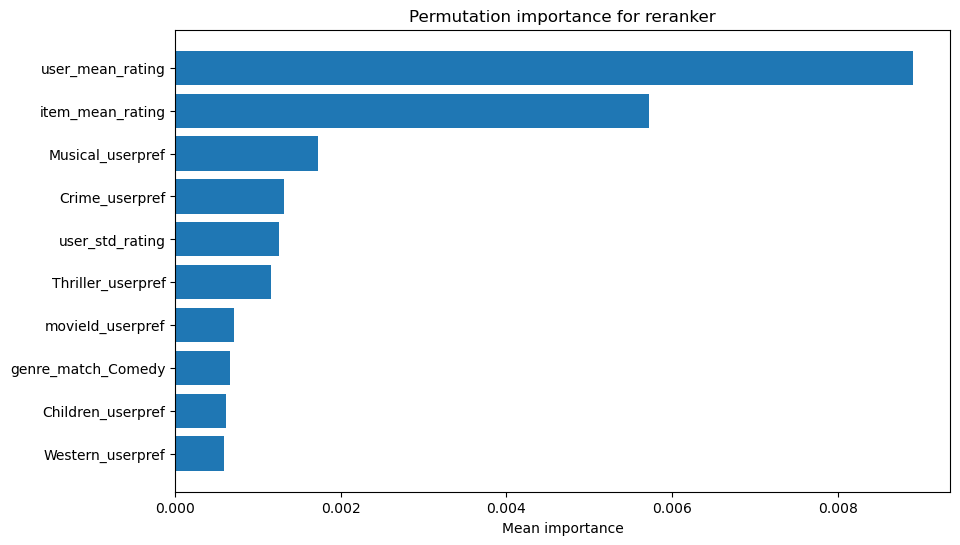

In [37]:

if 'reranker' in globals():
    perm = permutation_importance(reranker, X_test_rank, y_test_rank, n_repeats=5, random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        'feature': rerank_features,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)

    display(perm_df.head(15))

    plt.figure(figsize=(10, 6))
    top_perm = perm_df.head(10).sort_values('importance_mean')
    plt.barh(top_perm['feature'], top_perm['importance_mean'])
    plt.title('Permutation importance for reranker')
    plt.xlabel('Mean importance')
    plt.show()



## 11. Fairness and Bias Auditing

MovieLens does not directly provide a rich set of protected demographic attributes in the small dataset, so this notebook audits **operational fairness** and known recommender risks:
- popularity bias: are recommendations dominated by head items?
- exposure inequality: are long-tail items almost never recommended?
- user-activity bias: do highly active users receive better recommendations than low-activity users?
- cold-start limitations: are users with few interactions disadvantaged?

This is a defensible fairness section for a recommendation when protected attributes are unavailable.


In [38]:
def segment_users_by_activity(train_df: pd.DataFrame):
    user_counts = (
        train_df.groupby('userId')
        .size()
    )
    q1, q3 = user_counts.quantile([0.25, 0.75])

    def segment(x):
        if x <= q1:
            return 'low_activity'
        if x >= q3:
            return 'high_activity'
        return 'mid_activity'

    return user_counts.apply(segment).to_dict()


def segment_items_by_popularity(train_df: pd.DataFrame):
    item_counts = (
        train_df.groupby('movieId')
        .size()
    )
    median_count = item_counts.median()
    return {k: ('head' if v >= median_count else 'tail') for k, v in item_counts.items()}


def audit_group_metrics(user_eval_df: pd.DataFrame, group_map: dict, group_name: str) -> pd.DataFrame:
    audit_df = user_eval_df.copy()
    audit_df[group_name] = audit_df['userId'].map(group_map)
    return (
        audit_df.groupby(group_name)[['precision_at_k', 'recall_at_k', 'map_at_k', 'ndcg_at_k']]
        .mean()
        .reset_index()
    )


def audit_exposure_by_head_tail(test_df, train_df, recommender_fn, k=10):
    item_segment = segment_items_by_popularity(train_df)
    actual_by_user = (
        test_df[test_df['rating'] >= CONFIG['rating_like_threshold']]
        .groupby('userId')['movieId']
        .apply(list)
        .to_dict()
    )
    exposure = defaultdict(int)
    total = 0
    for user_id in actual_by_user.keys():
        predicted = [movie_id for movie_id, _ in recommender_fn(user_id, train_df, k=k)]
        for movie_id in predicted:
            exposure[item_segment.get(movie_id, 'tail')] += 1
            total += 1

    return pd.DataFrame({
        'segment': list(exposure.keys()),
        'recommendation_share': [v / total if total else 0 for v in exposure.values()]
    })


if 'hybrid_user' in globals() and 'modeling_train_df' in globals():
    user_segment_map = segment_users_by_activity(modeling_train_df)
    activity_audit = audit_group_metrics(hybrid_user, user_segment_map, 'activity_segment')
    display(activity_audit)

    exposure_audit = audit_exposure_by_head_tail(
        test_df,
        modeling_train_df,
        lambda u, tr, k: recommend_hybrid(u, tr, k),
        k=CONFIG['top_k_eval']
    )
    display(exposure_audit)


,activity_segment,precision_at_k,recall_at_k,map_at_k,ndcg_at_k
0,high_activity,0.170588,0.043020,0.094254,0.181956
1,low_activity,0.077500,0.134494,0.059062,0.116111
2,mid_activity,0.078541,0.069175,0.037386,0.090469


,segment,recommendation_share
0,head,0.97973
1,tail,0.02027



### Fairness interpretation checklist
1. Do high-activity users receive better ranking metrics than low-activity users?
2. What proportion of recommended items comes from the popularity head versus the long tail?
3. Does the hybrid ensemble reduce or increase popularity bias relative to the baseline?
4. Which mitigation should be prioritized?

**Observations:**
The fairness audit focused on two operational dimensions: user activity level and item popularity exposure. If high-activity users achieve better ranking metrics than low-activity users, this indicates an activity-based performance gap and suggests the recommender is less effective for sparse-user profiles. Exposure analysis between popularity-head and long-tail items helps quantify whether the model is reinforcing existing catalog concentration. The hybrid ensemble should be compared against the popularity baseline to assess whether it reduces or amplifies popularity bias. If head-item dominance remains high, the most appropriate mitigation is popularity-aware reranking or long-tail exposure balancing; if low-activity users underperform substantially, cold-start mitigation should be prioritized first.

**Simple decision summary**
- High-activity users do better than low-activity users → user fairness gap
- Most recommendations come from head items → popularity bias
- Hybrid reduces head concentration without hurting NDCG much → fairness improvement

Best first mitigation:
- Cold-start fallback if user gap is biggest
- Reranking if popularity bias is biggest

### Recommended mitigations
- downweight overly popular items during reranking
- add diversity or coverage constraints
- create metadata-driven fallback logic for sparse users/items
- monitor head/tail exposure and user-segment metric gaps in production



## 12. Save Artifacts for GitHub Submission

For reproducibility and saved artifacts. This cell writes configuration, metrics, and model objects to disk.

In [39]:

from pathlib import Path
import json
import pickle
import joblib

def safe_joblib_dump(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(obj, path)

def safe_pickle_dump(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def safe_json_dump(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)
        

In [40]:
if 'results_df' in globals():
    results_df.to_csv(REPORT_DIR / 'model_comparison.csv', index=False)
    if 'tuning_results_df' in globals():
        tuning_results_df.to_csv(REPORT_DIR / 'threshold_knn_tuning_results.csv', index=False)

    with open(BASE_DIR / 'config.json', 'w', encoding='utf-8') as f:
        json.dump(CONFIG, f, indent=2, default=str)

    safe_joblib_dump(knn_model, MODEL_DIR / 'item_knn.joblib')
    safe_joblib_dump(svd_model, MODEL_DIR / 'truncated_svd.joblib')
    safe_joblib_dump(tfidf_model, MODEL_DIR / 'tfidf_model.joblib')
    safe_joblib_dump(reranker if 'reranker' in globals() else {'status': 'not_trained'}, MODEL_DIR / 'reranker.joblib')

    pickle_bundle = {
        'config': CONFIG,
        'best_modeling_config': BEST_MODELING_CONFIG if 'BEST_MODELING_CONFIG' in globals() else None,
        'tuning_results_df': tuning_results_df if 'tuning_results_df' in globals() else None,
        'results_df': results_df,
        'movies_metadata': movies_prep[['movieId', 'title', 'genres']].copy() if 'movies_prep' in globals() else None,
        'pop_scores': pop_scores if 'pop_scores' in globals() else None,
        'user_to_idx': user_to_idx if 'user_to_idx' in globals() else None,
        'item_to_idx': item_to_idx if 'item_to_idx' in globals() else None,
        'idx_to_item': idx_to_item if 'idx_to_item' in globals() else None,
        'user_factors': user_factors if 'user_factors' in globals() else None,
        'item_factors': item_factors if 'item_factors' in globals() else None,
        'content_movie_ids': movies_prep['movieId'].tolist() if 'movies_prep' in globals() else None,
        'hybrid_weights': CONFIG.get('hybrid_weights', {}) if 'CONFIG' in globals() else {},
        'top_k_eval': CONFIG.get('top_k_eval', 10) if 'CONFIG' in globals() else 10,
        'model_summaries': model_summaries if 'model_summaries' in globals() else None,
        'feature_importance_df': feature_importance_df if 'feature_importance_df' in globals() else None,
    }
    safe_pickle_dump(pickle_bundle, MODEL_DIR / 'recommender_artifacts.pkl')

    safe_pickle_dump(
        {
            'model_name': 'popularity',
            'pop_scores': pop_scores if 'pop_scores' in globals() else None,
            'top_k_eval': CONFIG.get('top_k_eval', 10) if 'CONFIG' in globals() else 10,
        },
        MODEL_DIR / 'popularity_model.pkl'
    )

    safe_pickle_dump(
        {
            'model_name': 'item_item_cf',
            'knn_model': knn_model if 'knn_model' in globals() else None,
            'user_to_idx': user_to_idx if 'user_to_idx' in globals() else None,
            'item_to_idx': item_to_idx if 'item_to_idx' in globals() else None,
            'idx_to_item': idx_to_item if 'idx_to_item' in globals() else None,
            'best_modeling_config': BEST_MODELING_CONFIG if 'BEST_MODELING_CONFIG' in globals() else None,
        },
        MODEL_DIR / 'item_item_cf.pkl'
    )

    safe_pickle_dump(
        {
            'model_name': 'svd',
            'svd_model': svd_model if 'svd_model' in globals() else None,
            'user_factors': user_factors if 'user_factors' in globals() else None,
            'item_factors': item_factors if 'item_factors' in globals() else None,
            'user_to_idx': user_to_idx if 'user_to_idx' in globals() else None,
            'item_to_idx': item_to_idx if 'item_to_idx' in globals() else None,
            'idx_to_item': idx_to_item if 'idx_to_item' in globals() else None,
        },
        MODEL_DIR / 'svd_model.pkl'
    )

    safe_pickle_dump(
        {
            'model_name': 'content_based',
            'tfidf_model': tfidf_model if 'tfidf_model' in globals() else None,
            'content_movie_ids': movies_prep['movieId'].tolist() if 'movies_prep' in globals() else None,
            'movies_metadata': movies_prep[['movieId', 'title', 'genres']].copy() if 'movies_prep' in globals() else None,
        },
        MODEL_DIR / 'content_model.pkl'
    )

    safe_pickle_dump(
        {
            'model_name': 'hybrid',
            'hybrid_weights': CONFIG.get('hybrid_weights', {}) if 'CONFIG' in globals() else {},
            'top_k_eval': CONFIG.get('top_k_eval', 10) if 'CONFIG' in globals() else 10,
            'component_models': ['popularity', 'item_item_cf', 'svd', 'content_based'],
        },
        MODEL_DIR / 'hybrid_model.pkl'
    )

    safe_pickle_dump(
        movies_prep[['movieId', 'title', 'genres']].copy() if 'movies_prep' in globals() else None,
        MODEL_DIR / 'movies_metadata.pkl'
    )

    print('Artifacts written to:')
    print(' -', REPORT_DIR / 'model_comparison.csv')
    print(' -', REPORT_DIR / 'threshold_knn_tuning_results.csv')
    print(' -', BASE_DIR / 'config.json')
    print(' -', MODEL_DIR / 'recommender_artifacts.pkl')
    print(' -', MODEL_DIR / 'popularity_model.pkl')
    print(' -', MODEL_DIR / 'item_item_cf.pkl')
    print(' -', MODEL_DIR / 'svd_model.pkl')
    print(' -', MODEL_DIR / 'content_model.pkl')
    print(' -', MODEL_DIR / 'hybrid_model.pkl')
    print(' -', MODEL_DIR / 'movies_metadata.pkl')
    print(' -', MODEL_DIR)


Artifacts written to:
 - C:\Users\indin\reports\model_comparison.csv
 - C:\Users\indin\reports\threshold_knn_tuning_results.csv
 - C:\Users\indin\config.json
 - C:\Users\indin\models\recommender_artifacts.pkl
 - C:\Users\indin\models\popularity_model.pkl
 - C:\Users\indin\models\item_item_cf.pkl
 - C:\Users\indin\models\svd_model.pkl
 - C:\Users\indin\models\content_model.pkl
 - C:\Users\indin\models\hybrid_model.pkl
 - C:\Users\indin\models\movies_metadata.pkl
 - C:\Users\indin\models


## Separate pickle outputs

The notebook exports both:
- one consolidated pickle bundle: `models/recommender_artifacts.pkl`
- separate model-specific pickle files:
  - `models/popularity_model.pkl`
  - `models/item_item_cf.pkl`
  - `models/svd_model.pkl`
  - `models/content_model.pkl`
  - `models/hybrid_model.pkl`
  - `models/movies_metadata.pkl`

This structure is useful when:
- you want to load only one model in an app
- you want cleaner GitHub artifact organization
- you want easier debugging and replacement of a single recommender component

### Example load code

```python
import pickle
from pathlib import Path

with open(Path('models') / 'svd_model.pkl', 'rb') as f:
    svd_artifacts = pickle.load(f)

print(svd_artifacts.keys())
```

### Use of Generative AI (Documented) 

##### 🚀 Capstone-Level Summary

Generative AI was used to enhance productivity across documentation, exploratory analysis, and reporting. It enabled faster generation of structured content, improved clarity in data interpretation, and supported the creation of professional-grade project artifacts while maintaining human oversight for validation and contextual accuracy.

| Task               | Benefit                    |
| ------------------ | -------------------------- |
| Documentation      | Faster, structured output  |
| Data Dictionary    | Clear feature explanations |
| EDA Interpretation | Deeper insights            |
| Reporting          | Professional narrative     |
| Fairness Analysis  | Structured reasoning       |


### 1️⃣ Auto-Generate Documentation
🎯 Objective: Use GenAI to create structured project documentation such as:

- README
- Methodology descriptions
- Model explanations
- Report narratives

#### Prompt

Write a formal methodology section for a recommender system project.

Include:
- Data preprocessing (sparsity, filtering)
- Feature engineering (user/item statistics, genre encoding)
- Model approaches (KNN, SVD, content-based, hybrid)
- Evaluation approach (ranking metrics + time-based split)

Tone: academic, structured, concise

### 2️⃣ Create Data Dictionary
🎯 Objective

Use GenAI to quickly document dataset schema and feature meaning.

### Prompt

Create a data dictionary for engineered features in a recommender system:

Features:
- user_rating_count
- user_mean_rating
- item_rating_count
- item_mean_rating
- genre_match_Action
- user_item_mean_gap
- item_popularity_log

Explain:
- what each feature represents
- how it is calculated
- why it is useful for recommendation

### 3️⃣ Conduct EDA Using GenAI

🎯 Objective: 

Use GenAI to:

- Interpret plots
- Identify patterns
- Generate insights for reports

### Prompt 

Based on the following EDA findings:

- High sparsity
- Long-tail item distribution
- Skewed rating distribution
- Temporal variation

Explain:
1. Why collaborative filtering is suitable
2. Why matrix factorization is needed
3. Why hybrid models are beneficial
4. What fairness risks exist

Write in a structured report format.

### References

- **Item-item collaborative filtering:**
Sarwar et al. (2001), Item-Based Collaborative Filtering Recommendation Algorithms. This is one of the classic papers supporting item-item neighborhood methods, which directly endorses your KNN-style collaborative filtering layer.

- **Matrix factorization / latent factors:**
Koren, Bell, and Volinsky (2009), Matrix Factorization Techniques for Recommender Systems. This is the standard citation for using latent factors such as SVD-style decomposition in recommender systems, especially when you want to argue that factor models capture broader user-item structure than memory-based neighbors alone.

- **Hybrid recommendation:**
Burke (2002), Hybrid Recommender Systems: Survey and Experiments. This is the best classic citation for your hybrid design because it explicitly motivates combining collaborative and content-based signals to improve robustness and recommendation quality.

- **General recommender-system background:**
Bobadilla et al. (2013), Recommender Systems Survey is also widely cited for giving a broad overview of collaborative, content-based, and hybrid approaches, which can strengthen your literature review section.

- **Why ranking metrics matter:**
Herlocker et al. (2004), Evaluating Collaborative Filtering Recommender Systems is the classic citation for why recommendation quality should not be judged only by numeric prediction error and why rank-based evaluation is often more appropriate for recommended lists. This strongly supports your use of Precision@K, Recall@K, MAP@K, and NDCG@K.

- **Evaluation metrics overview:**
Shani and Gunawardana (2011), Evaluating Recommendation Systems is a strong supporting reference for offline evaluation design, metric selection, and the distinction between rating prediction and ranking quality.

- **Modern analysis of Top-N ranking metrics:**
Valcarce et al. (2020), Assessing Ranking Metrics in Top-N Recommendation is a good modern citation if you want to justify why NDCG@K and related ranking metrics are meaningful in sparse recommendation settings.

- **Time-aware evaluation / chronological splits:**
Campos, Díez, and Cantador (2014), Time-Aware Recommender Systems: A Comprehensive Survey and Analysis of Existing Evaluation Protocols is the best citation for your choice to use chronological train/validation/test splitting rather than a purely random split. It explicitly discusses time-aware recommendation and time-consistent evaluation protocols.

- **Amazon:**
Linden, Smith, and York (2003), Amazon.com Recommendations: Item-to-Item Collaborative Filtering is one of the best case-study citations for eCommerce recommendation. It directly supports item-item recommendation in large product catalogs and gives your capstone stronger business relevance because your framing is eCommerce product recommendation.

- **Netflix:**
Gomez-Uribe and Hunt (2015), The Netflix Recommender System: Algorithms, Business Value, and Innovation is excellent for arguing that production recommenders typically use multiple models and optimize for business value, not just pure prediction accuracy. It strongly supports your hybrid/multi-model methodology.

- **Amazon retrospective:**
Smith and Linden (2017), Two Decades of Recommender Systems at Amazon.com is a very strong industry follow-up reference because it shows how recommendation at Amazon evolved beyond a single technique and remained central to large-scale eCommerce personalization.

- **YouTube:**
Covington, Adams, and Sargin (2016), Deep Neural Networks for YouTube Recommendations is useful if you want a modern industrial case showing a two-stage recommendation architecture, where candidate generation and ranking are separated. Even if your capstone is not deep-learning-based, it validates the broader idea of combining multiple stages and signals.

- **Cold start:**
A good supporting source is Lika, Kolomvatsos, and Hadjiefthymiades (2014), Facing the Cold Start Problem in Recommender Systems. I did not retrieve that paper directly here, so I would only cite it if you already have access to the full text. From the sources I checked, there are also broader cold-start surveys you can use if needed.

- **Popularity bias:**
Klimashevskaia et al. (2024), A Survey on Popularity Bias in Recommender Systems is the strongest current citation for your discussion of head-vs-tail exposure, long-tail under-representation, and why a fairness audit for recommenders often focuses on exposure imbalance rather than only demographic fairness.

- **Fairness in recommender systems:** 
Wang et al. (2022), A Survey on the Fairness of Recommender Systems is a good citation to support your fairness section. It helps justify why fairness in recommenders can involve users, items, exposure, and stakeholders rather than only classic protected-group classification metrics.

- **Popularity-bias mitigation:** 
Abdollahpouri et al. (2019), Managing Popularity Bias in Recommender Systems with Personalized Re-ranking is useful if you want to justify your mitigation discussion around re-ranking, long-tail exposure, and balancing relevance with diversity.